# Deep Learning pour le Texte — NLP & Transformers
L'objectif de ce TP est d'explorer les représentations vectorielles de mots (*embeddings*) et les architectures Transformer appliquées à la classification de texte. Nous abordons successivement :
- Chargement et manipulation d'embeddings pré-entraînés (GloVe)
- Calcul de similarité cosinus entre phrases
- Classification sur un corpus jouet avec différentes architectures (BoW, MLP, Transformer)
- Fine-tuning d'un Transformer pré-entraîné (DistilBERT) sur le corpus IMDB

> **Note de lecture** : les sorties des cellules d'entraînement sont longues — elles permettent de suivre la convergence epoch par epoch. Chaque cellule est commentée ligne à ligne.


## Configuration de l'environnement


In [1]:
import torch
print(torch.__version__)  # vérification de la version PyTorch installée


2.4.1+cu121


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from tqdm import tqdm
from tqdm.autonotebook import tqdm  # barre de progression adaptative (notebook vs terminal)

import pandas as pd
import numpy as np

import transformers
print(transformers.__version__)  # vérification de la version Hugging Face Transformers


/tmp/ipykernel_154175/428297533.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


4.46.3


## Chargement d'embeddings et calculs de similarité

Pour débuter, nous utilisons GloVe (*Global Vectors for Word Representation*), un modèle d'embeddings pré-entraîné chargé via la librairie `gensim`.

**Théorie — GloVe :**
GloVe factorise la matrice de co-occurrence globale du corpus. Contrairement à Word2Vec (qui prédit les mots voisins via une fenêtre locale), GloVe minimise une erreur pondérée entre le produit scalaire de deux vecteurs et le log de leur fréquence de co-occurrence :
$$J = \sum_{i,j} f(X_{ij}) (w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$
où $X_{ij}$ est le nombre de fois que le mot $j$ apparaît dans le contexte du mot $i$, et $f$ est une fonction de pondération atténuant les co-occurrences très fréquentes.

**Résultat** : des vecteurs denses de dimension fixe (ici **50**) encodant la sémantique distributionnelle — les mots apparaissant dans des contextes similaires ont des vecteurs géométriquement proches.


In [3]:
!pip install gensim

import gensim.downloader as api

# Chargement du modèle GloVe pré-entraîné sur Wikipedia + Gigaword (6B tokens)
# Vocabulaire : 400 000 mots | Dimension : 50
# embeds['word'] retourne le vecteur numpy (dim=50) associé au mot
embeds = api.load("glove-wiki-gigaword-50")

print(embeds['book'])  # exemple : vecteur de dimension 50 pour le mot 'book'


[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0.14227
 -0.28125    0.098155  -0.17096    0.52408    0.31851   -0.089847
 -0.27223   -0.0088736]


In [4]:
# most_similar() exploite la géométrie de l'espace d'embeddings :
# la proximité est mesurée par similarité cosinus entre vecteurs.
# Les mots sémantiquement proches ont des vecteurs orientés dans des directions voisines,
# car ils apparaissent dans des contextes similaires dans le corpus d'entraînement.
help(embeds.most_similar)


Help on method most_similar in module gensim.models.keyedvectors:

most_similar(positive=None, negative=None, topn=10, clip_start=0, clip_end=None, restrict_vocab=None, indexer=None) method of gensim.models.keyedvectors.KeyedVectors instance
    Find the top-N most similar keys.
    Positive keys contribute positively towards the similarity, negative keys negatively.
    
    This method computes cosine similarity between a simple mean of the projection
    weight vectors of the given keys and the vectors for each key in the model.
    The method corresponds to the `word-analogy` and `distance` scripts in the original
    word2vec implementation.
    
    Parameters
    ----------
    positive : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
        List of keys that contribute positively. If tuple, second element specifies the weight (default `1.0`)
    negative : list of (str or int or ndarray) or list of ((str,float) or (int,floa

Afficher les 5 mots les plus proches de `"cat"` via la méthode `model.most_similar`.


In [5]:
# most_similar("cat", topn=5) : recherche les 5 vecteurs les plus proches de celui de "cat"
# selon la similarité cosinus : cos(u, v) = (u·v) / (||u|| · ||v||)
# Résultat attendu : des animaux domestiques ou petits mammifères (dog, kitten, rabbit...)
# → illustre la propriété fondamentale : proximité géométrique = proximité sémantique
print(embeds.most_similar("cat", topn=5))


[('dog', 0.9218006134033203), ('rabbit', 0.8487821221351624), ('monkey', 0.8041081428527832), ('rat', 0.7891963124275208), ('cats', 0.7865270376205444)]


In [6]:
# La similarité cosinus est bornée dans [-1, 1] :
#   1   → vecteurs identiques (même direction)
#   0   → vecteurs orthogonaux (aucune relation)
#  -1   → vecteurs opposés
# apple et banana sont tous deux des fruits → similarité élevée (~0.5-0.7)
# apple et rat appartiennent à des catégories éloignées → similarité faible (~0.1-0.2)
# Cette mesure est invariante à la norme : seule l'orientation des vecteurs compte.
print(embeds.similarity("apple", "banana"))
print(embeds.similarity("apple", "rat"))


0.5607928
0.2039362


### Out Of Vocabulary (OOV)

Un modèle basé sur des embeddings de mots possède un **vocabulaire fermé** fixé à l'entraînement. Tout mot absent de ce vocabulaire est dit *Out Of Vocabulary* (OOV).

**Théorie — Causes et solutions :**
- Mots rares absents du corpus d'entraînement (noms propres, termes techniques)
- Fautes de frappe (`"truckks"`)
- Néologismes (`"covid"` pour un modèle antérieur à 2020)
- Mots composés (`"truckmegatruck"`)

La stratégie adoptée ici consiste à **ignorer** les tokens OOV et à les remplacer par un vecteur de padding nul. Une approche plus robuste — utilisée dans la section suivante — repose sur les tokenizers **BPE** (*Byte Pair Encoding*), qui décomposent tout mot en sous-mots connus.


Pour éviter ce problème, il convient de vérifier la présence de chaque mot dans le vocabulaire via `vocab.keys()`.


In [7]:
# key_to_index : dictionnaire Python { mot → indice } pour les 400 000 mots du vocabulaire
# La vérification d'appartenance est en O(1) grâce à la structure de table de hachage.
vocab = embeds.key_to_index.keys()
np.random.choice(list(vocab), 5)  # 5 mots aléatoires du vocabulaire (pour exploration)

x = "covid"
if x in vocab:
    print(embeds[x])
else:
    print("oov")  # 'covid' absent : le modèle GloVe a été entraîné avant sa généralisation


oov


### Visualisation des embeddings avec t-SNE

Pour visualiser des embeddings de dimension 50 en 2D, on recourt à **t-SNE**.

**Théorie — t-SNE :**
t-SNE (*t-distributed Stochastic Neighbor Embedding*) est une technique de réduction de dimensionnalité **non-linéaire**. Elle modélise les similarités entre points dans l'espace de haute dimension (ici 50D) comme des probabilités gaussiennes, puis cherche une représentation 2D préservant ces mêmes similarités (distribution en t de Student). Elle conserve principalement la **structure locale** : les voisins proches en 50D restent proches en 2D.

Sur notre jeu de mots (animaux + véhicules), on s'attend à observer **deux clusters distincts**.


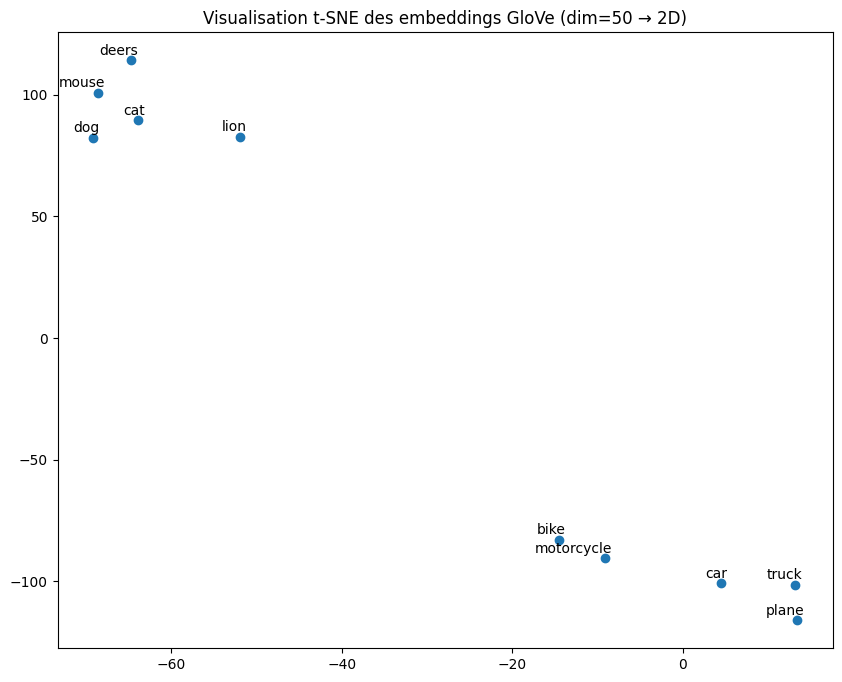

In [8]:
words = ['cat','mouse','dog','car','truck','motorcycle','bike','lion','plane','deers']

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def tsne_plot(model, words, n_components=2, perplexity=40):
    """Réduit les embeddings en 2D par t-SNE et affiche le résultat annoté."""
    labels, tokens = [], []
    vocab = model.key_to_index.keys()

    for word in words:
        if word in vocab:
            tokens.append(model[word])
            labels.append(word)

    tokens = np.array(tokens)

    # perplexity : équilibre entre structure locale et globale (typiquement 5-50)
    # Doit être strictement inférieur au nombre de points → valeur réduite ici (10 mots seulement)
    tsne_model = TSNE(perplexity=perplexity, n_components=n_components,
                      init='pca', n_iter=2500, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    fig = plt.figure(figsize=(10, 8))
    plt.scatter(new_values[:, 0], new_values[:, 1])
    for i in range(len(new_values)):
        plt.annotate(labels[i],
                     xy=(new_values[i][0], new_values[i][1]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right', va='bottom')
    plt.title("Visualisation t-SNE des embeddings GloVe (dim=50 → 2D)")
    plt.show()
    return new_values, labels

# perplexity=2 est requis car t-SNE exige perplexity < nombre de points (ici 10)
# On devrait observer deux regroupements : animaux d'un côté, véhicules de l'autre
new_values, labels = tsne_plot(embeds, words, n_components=2, perplexity=2)


In [9]:
import sys
print(sys.executable)  # vérification de l'interpréteur Python utilisé dans ce notebook


/usr/bin/python3


### Indexation des embeddings

En pratique, les entrées des modèles PyTorch ne contiennent pas directement les vecteurs d'embeddings, mais des **indices entiers** référençant les mots dans le vocabulaire.

**Théorie — `nn.Embedding` :**
`nn.Embedding` est une **table de lookup** différentiable : étant donné un indice $i$, elle retourne la $i$-ème ligne de sa matrice de poids $W \in \mathbb{R}^{V \times d}$ ($V$ = taille du vocabulaire, $d$ = dimension). Cette approche est bien plus efficace que de passer des vecteurs flottants en entrée (un entier vs 50 flottants), et les gradients peuvent remonter jusqu'aux embeddings pour les mettre à jour lors de l'entraînement.


In [10]:
print(embeds.key_to_index["book"])          # mot → indice entier (ex : 539)
print(embeds.index_to_key[539])             # indice → mot (opération inverse)

# Deux façons équivalentes de récupérer le vecteur du mot "book" :
print(embeds["book"])                                            # via la clé string
print(embeds.vectors[embeds.key_to_index["book"]])              # via l'indice (lookup matriciel)

# La matrice complète des embeddings : (nb_mots, dim_embedding)
# 400 000 mots × 50 dimensions = 20M flottants ≈ 80 Mo en float32
print(embeds.vectors.shape)


539
book
[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0.14227
 -0.28125    0.098155  -0.17096    0.52408    0.31851   -0.089847
 -0.27223   -0.0088736]
[-0.0076543  0.93456   -0.73189   -0.55162    0.76977    0.35925
 -1.1365    -1.1632     0.34214    0.29145   -0.8711     0.9197
 -0.47069   -0.22834    1.4777    -0.81714   -0.17466   -0.51093
 -0.28354    0.23292    0.71832    0.23414    0.49443    0.35483
  0.76889   -1.4374    -1.7457    -0.28994   -0.10156   -0.36959
  2.5502    -1.0581    -0.049416  -0.25524   -0.63303    0.02671
 -0.18733    0.20206   -0.26288   -0.41418    0.83473   -0

#### Exercice 1 : Matrice de similarité de phrases

On calcule la similarité cosinus entre toutes les paires de phrases du dataset jouet suivant :


In [11]:
tdf = pd.DataFrame([
    ['the road is straight', 'Y'],
    ['the black cat plays with a ball', 'N'],
    ['a big dog with a ball', 'N'],
    ['dog and cat are together', 'N'],
    ['traffic jam on the 6th road', 'Y'],
    ['white bird on a big tree', 'N'],
    ['a big truck', 'Y'],
    ['two cars crashed', 'Y'],
    ['two deers in a field', 'N'],
    ['I like ridding my bike','Y'],
    ['a lion in the savane','N'],
    ['a motorcycle rides on the road','Y'],
    ['it is a bike, it is not a flamingo', 'Y'],
    ['it is not a bike, it is a flamingo', 'N'],
    ['a mouse bitten by a cat','N'],
    ['two pigs in the mood','N'],
    ['take a plane is sometimes slower than taking train','Y'],
    ['take the highway','Y']
], columns=['text', 'label'])
tdf

,text,label
0,the road is straight,Y
1,the black cat plays with a ball,N
2,a big dog with a ball,N
3,dog and cat are together,N
4,traffic jam on the 6th road,Y
5,white bird on a big tree,N
6,a big truck,Y
7,two cars crashed,Y
8,two deers in a field,N
9,I like ridding my bike,Y


Pour chaque phrase, on moyenne les embeddings de ses mots, puis on normalise le vecteur résultant. La similarité entre deux phrases se calcule alors par simple **produit scalaire** (équivalent à la similarité cosinus après normalisation).

**Théorie — Bag-of-Words avec embeddings (BoW) :**
$$\vec{s} = \frac{1}{n} \sum_{i=1}^{n} \vec{w}_i, \quad \text{puis} \quad \vec{s} \leftarrow \frac{\vec{s}}{\|\vec{s}\|}$$

Après normalisation, le produit scalaire $\vec{s}_i \cdot \vec{s}_j = \cos(\vec{s}_i, \vec{s}_j)$.

**Limites fondamentales de cette représentation :**
1. *Invariance à l'ordre* : `"chat mange souris"` ≡ `"souris mange chat"` → même vecteur
2. *Ambiguïté lexicale ignorée* : `"bank"` (rive) ≡ `"bank"` (banque)
3. *Tokens OOV ignorés* : les mots absents du vocabulaire sont simplement omis


In [12]:
import gensim

def getlistwordsentence2(text):
    """Tokenise chaque phrase en liste de mots (gère la ponctuation via gensim)."""
    ret = []
    for sentence in text:
        ret.append(list(gensim.utils.tokenize(sentence)))
    return ret

text_wordlist = getlistwordsentence2(tdf['text'])
print(text_wordlist)

def getvectors(wordslist, normalize=True):
    """
    Calcule la représentation vectorielle de chaque phrase par moyenne des embeddings.

    Algorithme :
      1. Filtrer les mots OOV (absents du vocabulaire GloVe)
      2. Récupérer les vecteurs des mots connus via embeds[mot]
      3. Calculer la moyenne → représentation BoW de dim fixe (50)
      4. Normaliser en norme L2 pour que le produit scalaire = similarité cosinus

    Note : la moyenne est l'agrégateur le plus simple pour une séquence de longueur variable.
    Des approches plus puissantes existent : LSTM, attention, token [CLS] de BERT.
    """
    vocab = embeds.key_to_index.keys()
    vectors = []
    sentences_out = []

    for words in wordslist:
        # Filtrage OOV : on ne retient que les mots présents dans le vocabulaire GloVe
        known_words = [w.lower() for w in words if w.lower() in vocab]

        if len(known_words) == 0:
            # Cas dégénéré : phrase entièrement OOV → vecteur nul (neutre)
            vec = torch.zeros(embeds.vector_size)
        else:
            # Empilement en matrice (nb_mots_connus × 50), puis moyenne sur la dim 0
            vecs = torch.tensor(
                np.array([embeds[w] for w in known_words]),
                dtype=torch.float
            )
            vec = vecs.mean(dim=0)  # → tenseur de dimension 50

        if normalize:
            # Normalisation L2 : vec ← vec / ||vec||
            # Après normalisation : ||vec|| = 1, produit scalaire = cosinus
            norm = vec.norm()
            if norm > 0:
                vec = vec / norm

        vectors.append(vec)
        sentences_out.append(" ".join(words))

    return torch.stack(vectors), sentences_out


x, sentences = getvectors(text_wordlist, True)
print(x.shape)   # (18 phrases × 50 dimensions)
print(x)

def getSims(x):
    """
    Calcule la matrice de similarité cosinus (N×N) entre toutes les paires de phrases.

    Formule : S = X @ X.T
    Après normalisation des lignes de X, X[i] · X[j] = cos(angle(X[i], X[j])).
    Propriétés :
      S[i,i] = 1        (une phrase est identique à elle-même)
      S[i,j] proche de 1 → phrases sémantiquement proches
      S[i,j] proche de 0 → phrases sans lien sémantique apparent
    """
    return (x @ x.T).numpy()

innerproducts = getSims(x)


[['the', 'road', 'is', 'straight'], ['the', 'black', 'cat', 'plays', 'with', 'a', 'ball'], ['a', 'big', 'dog', 'with', 'a', 'ball'], ['dog', 'and', 'cat', 'are', 'together'], ['traffic', 'jam', 'on', 'the', 'th', 'road'], ['white', 'bird', 'on', 'a', 'big', 'tree'], ['a', 'big', 'truck'], ['two', 'cars', 'crashed'], ['two', 'deers', 'in', 'a', 'field'], ['I', 'like', 'ridding', 'my', 'bike'], ['a', 'lion', 'in', 'the', 'savane'], ['a', 'motorcycle', 'rides', 'on', 'the', 'road'], ['it', 'is', 'a', 'bike', 'it', 'is', 'not', 'a', 'flamingo'], ['it', 'is', 'not', 'a', 'bike', 'it', 'is', 'a', 'flamingo'], ['a', 'mouse', 'bitten', 'by', 'a', 'cat'], ['two', 'pigs', 'in', 'the', 'mood'], ['take', 'a', 'plane', 'is', 'sometimes', 'slower', 'than', 'taking', 'train'], ['take', 'the', 'highway']]
torch.Size([18, 50])
tensor([[-2.0428e-03,  1.2294e-01, -2.5053e-02,  3.8993e-02,  3.7583e-02,
          2.6519e-02, -1.1185e-01, -2.6247e-02,  2.7497e-02, -9.6953e-02,
         -6.0345e-02, -6.9913e

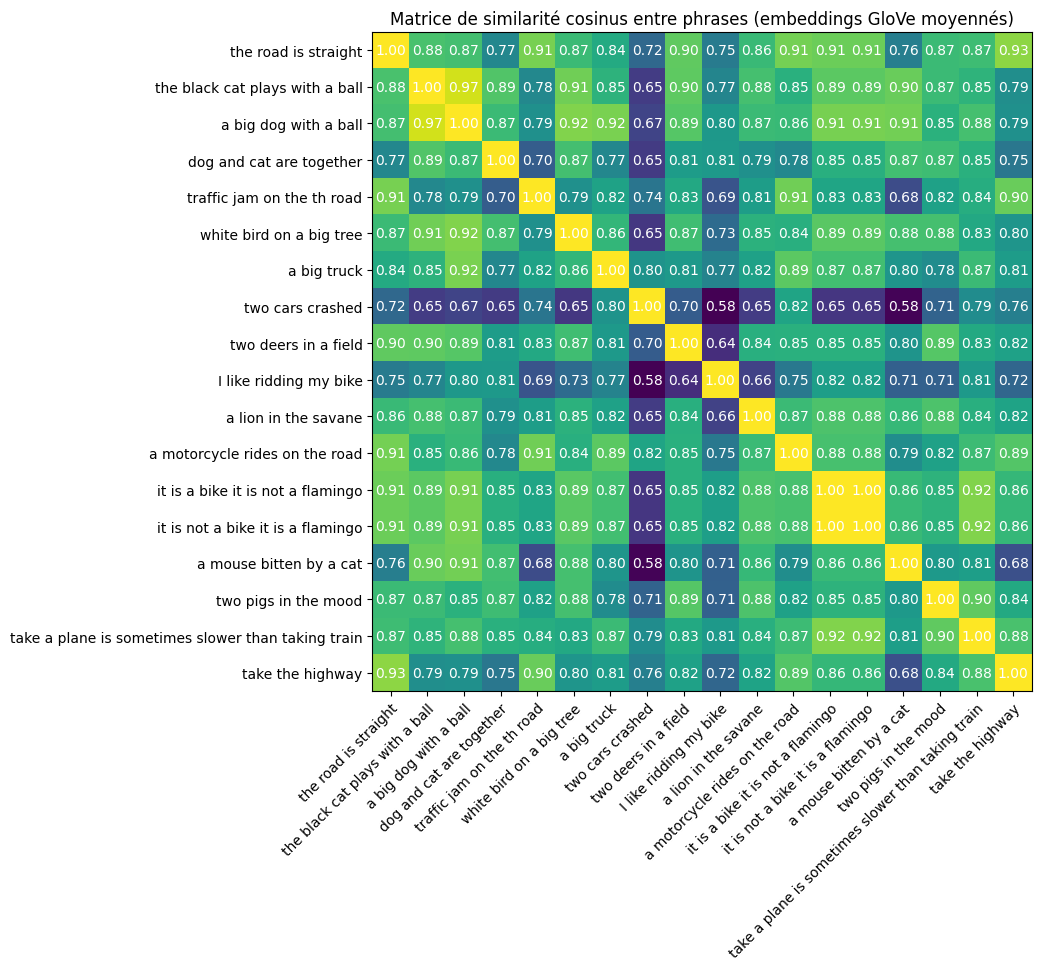

In [13]:
def visual_similarity_matrix(innerproducts):
    """Affiche la matrice de similarité cosinus sous forme de heatmap annotée."""
    fig, ax = plt.subplots()
    im = ax.imshow(innerproducts)

    ax.set_xticks(np.arange(len(sentences)))
    ax.set_yticks(np.arange(len(sentences)))
    ax.set_xticklabels(sentences)
    ax.set_yticklabels(sentences)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(len(sentences)):
        for j in range(len(sentences)):
            text = ax.text(j, i, "%.2f" % innerproducts[i, j],
                           ha="center", va="center", color="w")

    ax.set_title("Matrice de similarité cosinus entre phrases (embeddings GloVe moyennés)")
    fig.tight_layout()
    fig.set_size_inches(20, 20)
    plt.show()

visual_similarity_matrix(innerproducts)
# Lecture : un bloc clair en haut-gauche regroupe les phrases liées au transport (Y)
# et un bloc clair en bas-droit regroupe les phrases liées aux animaux (N)


## Classification sur le corpus jouet

On s'intéresse maintenant à l'apprentissage d'un classifieur sur le dataset précédent. Le jeu de validation utilisé est le suivant :


In [14]:
vdf = pd.DataFrame([
    ['the bike drives on the road', 'Y'],
    ['a lion and a cat in a tree', 'N'],
    ['two cars crashed', 'Y'],
    ['i always go to work by bike', 'Y'],
    ['i have no animal at home', 'N'],
    ['dogs like cheese', 'N'],
    ['a pink flamingo','N'],
    ['trucks','Y'],
    ['truckks','Y'],
    ['truckmegatruck', 'Y'],
    ['a text about trucks, not animals','Y'],
    ['a text about animals, not trucks','N'],
    ['doggs','N']
], columns=['text', 'label'])
vdf

,text,label
0,the bike drives on the road,Y
1,a lion and a cat in a tree,N
2,two cars crashed,Y
3,i always go to work by bike,Y
4,i have no animal at home,N
5,dogs like cheese,N
6,a pink flamingo,N
7,trucks,Y
8,truckks,Y
9,truckmegatruck,Y


La première étape consiste à transformer les données brutes en tenseurs exploitables : conversion des labels en entiers, tokenisation des phrases et construction des batchs avec padding.


In [15]:
import datasets
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(tdf)
validation_dataset = Dataset.from_pandas(vdf)
print(train_dataset, validation_dataset)
print(train_dataset["text"])

# pad_idx : indice fictif utilisé pour le padding des séquences courtes
# Choisi juste après le dernier mot du vocabulaire GloVe (indice 400 000)
# La couche nn.Embedding sera construite avec vocab_size+1 lignes pour inclure cet indice
pad_idx = embeds.vectors.shape[0]  # = 400 000

def preprocess_function(examples):
    """
    Convertit les textes bruts en séquences d'indices compatibles avec nn.Embedding.

    Étapes :
      1. Tokenisation : découpage en liste de mots via gensim.tokenize
      2. Indexation : mot → indice GloVe ; si OOV → pad_idx (ignoré par le masque)
      3. Binarisation des labels : 'Y' → 1, 'N' → 0

    Chaque phrase est représentée par une séquence d'entiers [idx1, idx2, ...]
    de longueur variable. Le padding à longueur fixe est appliqué dans data_collator.
    """
    vocab = embeds.key_to_index
    inputs = getlistwordsentence2(examples["text"])
    inputs = [
        [(vocab[word] if word in vocab else pad_idx) for word in sentence]
        for sentence in inputs
    ]
    labels = [(1 if l == 'Y' else 0) for l in examples["label"]]
    return {"input_ids": inputs, "labels": labels}


train_dataset = train_dataset.map(
    preprocess_function, batched=True,
    remove_columns=train_dataset.features.keys(),
    load_from_cache_file=True
)
print(train_dataset)
print(train_dataset["input_ids"])

validation_dataset = validation_dataset.map(
    preprocess_function, batched=True,
    remove_columns=validation_dataset.features.keys(),
    load_from_cache_file=True
)
print(validation_dataset)
print(validation_dataset["input_ids"])


Dataset({
    features: ['text', 'label'],
    num_rows: 18
}) Dataset({
    features: ['text', 'label'],
    num_rows: 13
})
['the road is straight', 'the black cat plays with a ball', 'a big dog with a ball', 'dog and cat are together', 'traffic jam on the 6th road', 'white bird on a big tree', 'a big truck', 'two cars crashed', 'two deers in a field', 'I like ridding my bike', 'a lion in the savane', 'a motorcycle rides on the road', 'it is a bike, it is not a flamingo', 'it is not a bike, it is a flamingo', 'a mouse bitten by a cat', 'two pigs in the mood', 'take a plane is sometimes slower than taking train', 'take the highway']


Map: 100%|██████████| 18/18 [00:00<00:00, 571.98 examples/s]


Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 18
})
[[0, 586, 14, 1362], [0, 521, 5450, 1381, 17, 7, 1083], [7, 365, 2926, 17, 7, 1083], [2926, 5, 5450, 32, 600], [1596, 8202, 13, 0, 14358, 586], [298, 2632, 13, 7, 365, 2654], [7, 365, 2575], [55, 1277, 3732], [55, 134183, 6, 7, 610], [400000, 117, 40085, 192, 7696], [7, 6657, 6, 0, 232439], [7, 7213, 9371, 13, 0, 586], [20, 14, 7, 7696, 20, 14, 36, 7, 35115], [20, 14, 36, 7, 7696, 20, 14, 7, 35115], [7, 7571, 22022, 21, 7, 5450], [55, 9609, 6, 0, 5030], [190, 7, 1313, 14, 1071, 6914, 73, 582, 1470], [190, 0, 1883]]


Map: 100%|██████████| 13/13 [00:00<00:00, 4041.95 examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 13
})
[[0, 7696, 5919, 13, 0, 586], [7, 6657, 5, 7, 5450, 6, 7, 2654], [55, 1277, 3732], [41, 690, 242, 4, 161, 21, 7696], [41, 33, 84, 2694, 22, 163], [3876, 117, 5795], [7, 5491, 35115], [3597], [400000], [400000], [7, 2829, 59, 3597, 36, 2430], [7, 2829, 59, 2430, 36, 3597], [400000]]


In [16]:
from torch.utils.data import DataLoader
from transformers.trainer_pt_utils import LengthGroupedSampler, Sampler, get_length_grouped_indices

batchsize = 4
megabatch_mul = 16

class LengthGroupedSampler(Sampler):
    """
    Sampler regroupant les séquences de longueurs similaires dans les mêmes batchs.

    Motivation : dans un batch, toutes les séquences doivent partager la même longueur
    (tenseur rectangulaire). On les padde jusqu'à la longueur de la plus longue du batch.
    Si les longueurs sont très hétérogènes, une quantité importante de padding inutile est générée,
    ce qui ralentit l'entraînement et biaise le gradient (tokens de padding artificiels).

    Algorithme :
      1. Tirage d'une permutation aléatoire des indices
      2. Découpage en mégabatchs de taille batch_size × megabatch_mul
      3. Tri par longueur décroissante à l'intérieur de chaque mégabatch
      4. Découpage final en batchs de taille batchsize

    megabatch_mul élevé → moins d'aléatoire, moins de padding (bénéfique pour le GPU)
    megabatch_mul = 1  → batchs purement aléatoires, padding potentiellement important
    """
    def __init__(self, batch_size, dataset, megabatch_mul=None):
        self.batch_size = batch_size
        self.lengths = [len(sample["input_ids"]) for sample in dataset]
        self.megabatch_mul = megabatch_mul

    def __len__(self):
        return len(self.lengths)

    def __iter__(self):
        indices = get_length_grouped_indices(self.lengths, self.batch_size, self.megabatch_mul)
        return iter(indices)


def data_collator(batch):
    """
    Assemble un batch de samples en tenseurs PyTorch avec padding dynamique.

    Chaque séquence est paddée jusqu'à la longueur de la plus longue du batch courant
    (et non du dataset entier), ce qui minimise la quantité de padding par batch.

    Retourne :
      - 'labels'    : tenseur (batch_size,) d'entiers 0 ou 1
      - 'input_ids' : tenseur (batch_size, max_seq_len) d'indices de mots
                      les positions paddées contiennent pad_idx
    """
    ret = {}
    first = batch[0]
    dtype = torch.long if type(first["labels"]) is int else torch.float
    ret["labels"] = torch.tensor([f["labels"] for f in batch], dtype=dtype)

    longest = max([len(l["input_ids"]) for l in batch])
    # np.pad complète chaque séquence à droite avec pad_idx jusqu'à la longueur maximale
    s = np.stack([
        np.pad(x["input_ids"], (0, longest - len(x["input_ids"])), constant_values=pad_idx)
        for x in batch
    ])
    ret["input_ids"] = torch.tensor(s)
    return ret


train_sampler = LengthGroupedSampler(batchsize, train_dataset, megabatch_mul)
train_loader = DataLoader(train_dataset, batchsize, sampler=train_sampler,
                          collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in train_loader:
    print(data)

test_sampler = LengthGroupedSampler(batchsize, validation_dataset, megabatch_mul)
test_loader = DataLoader(validation_dataset, batchsize, sampler=test_sampler,
                         collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in test_loader:
    print(data)


{'labels': tensor([1, 0, 1, 0]), 'input_ids': tensor([[   190,      7,   1313,     14,   1071,   6914,     73,    582,   1470],
        [    20,     14,     36,      7,   7696,     20,     14,      7,  35115],
        [    20,     14,      7,   7696,     20,     14,     36,      7,  35115],
        [     0,    521,   5450,   1381,     17,      7,   1083, 400000, 400000]])}
{'labels': tensor([1, 0, 1, 0]), 'input_ids': tensor([[ 1596,  8202,    13,     0, 14358,   586],
        [    7,  7571, 22022,    21,     7,  5450],
        [    7,  7213,  9371,    13,     0,   586],
        [  298,  2632,    13,     7,   365,  2654]])}
{'labels': tensor([0, 0, 1, 0]), 'input_ids': tensor([[     7,    365,   2926,     17,      7,   1083],
        [    55,   9609,      6,      0,   5030, 400000],
        [400000,    117,  40085,    192,   7696, 400000],
        [    55, 134183,      6,      7,    610, 400000]])}
{'labels': tensor([0, 0, 1, 1]), 'input_ids': tensor([[  2926,      5,   5450,     32,  

In [17]:
def batch_decode(input_ids):
    """Décode un tenseur d'indices en phrases lisibles (les tokens de padding sont ignorés)."""
    x = input_ids.data
    x = [" ".join([embeds.index_to_key[i] for i in s if i != pad_idx]) for s in x]
    return x

for data in test_loader:
    print(data)
    print(batch_decode(data["input_ids"]))
# Note : "truckmegatruck" → chaîne vide, car tous ses tokens sont OOV (= pad_idx)
# Ce problème sera résolu dans la section suivante grâce au tokenizer BPE de DistilBERT


{'labels': tensor([0, 1, 0, 0]), 'input_ids': tensor([[     7,   6657,      5,      7,   5450,      6,      7,   2654],
        [    41,    690,    242,      4,    161,     21,   7696, 400000],
        [    41,     33,     84,   2694,     22,    163, 400000, 400000],
        [     7,   2829,     59,   2430,     36,   3597, 400000, 400000]])}
['a lion and a cat in a tree', 'i always go to work by bike', 'i have no animal at home', 'a text about animals not trucks']
{'labels': tensor([1, 1, 1, 0]), 'input_ids': tensor([[     0,   7696,   5919,     13,      0,    586],
        [     7,   2829,     59,   3597,     36,   2430],
        [    55,   1277,   3732, 400000, 400000, 400000],
        [     7,   5491,  35115, 400000, 400000, 400000]])}
['the bike drives on the road', 'a text about trucks not animals', 'two cars crashed', 'a pink flamingo']
{'labels': tensor([0, 1, 0, 1]), 'input_ids': tensor([[  3876,    117,   5795],
        [400000, 400000, 400000],
        [400000, 400000, 400000

### Modèle de classification simple — `MyModel`

On construit un classifieur léger avec PyTorch. L'architecture est :
`Embedding → MoyenneMasquée → Tanh → Dropout → Linear(→ 2 classes)`

**Théorie :**
- `nn.Embedding(V+1, d, padding_idx=P)` : table de lookup de taille $(V+1) \times d$. Avec `padding_idx=P`, deux comportements sont garantis : (1) le gradient de la ligne $P$ est toujours nul → le vecteur de padding reste à zéro ; (2) la ligne $P$ est initialisée à zéro. Les tokens de padding ne contribuent ainsi ni à la représentation ni à la mise à jour des poids.
- **Moyenne masquée** : seuls les tokens réels (non-padding) sont moyennés, en divisant par leur nombre effectif. Sans masque, la représentation serait biaisée vers zéro pour les phrases courtes.
- **weight_decay** (régularisation L2) : pénalise les normes de vecteurs trop grandes, empêchant les embeddings de s'éparpiller dans des directions arbitraires — essentiel avec un petit corpus.


In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam


class MyModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx, dropout=0.3):
        """
        vocab_size : taille du vocabulaire (400 000 pour GloVe)
        embed_dim  : dimension des embeddings (50 pour GloVe-50, 768 pour DistilBERT)
        pad_idx    : indice du token de padding (gradient nul garanti par PyTorch)
        dropout    : taux de dropout appliqué avant la couche linéaire finale
        """
        super().__init__()

        # Table de lookup de taille (vocab_size + 1) × embed_dim
        # +1 car pad_idx = vocab_size est un indice fictif hors vocabulaire
        # padding_idx=pad_idx : vecteur nul et gradient nul pour cet indice
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=pad_idx)

        self.dropout = nn.Dropout(dropout)

        # Couche de sortie : embed_dim → 2 logits (classe 0 : N, classe 1 : Y)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        """
        x : tenseur (batch_size, seq_len) d'indices de mots (entiers longs)

        Étapes :
          1. Lookup embeddings    : (batch, seq_len) → (batch, seq_len, embed_dim)
          2. Masque de padding    : booléen (batch, seq_len, 1), vrai si token réel
          3. Somme masquée / nb tokens réels → représentation BoW non biaisée
          4. Activation tanh ∈ (-1, 1) : compression non-linéaire de la représentation
          5. Dropout              : régularisation stochastique (actif en train, désactivé en eval)
          6. Linear               → 2 logits bruts (non normalisés ; softmax intégré dans CrossEntropyLoss)
        """
        embedded = self.embedding(x)    # (batch, seq_len, embed_dim)

        # Masque : 1 pour les vrais tokens, 0 pour le padding
        # unsqueeze(-1) pour broadcaster sur la dimension embed_dim
        mask = (x != self.embedding.padding_idx).float().unsqueeze(-1)

        # Somme pondérée par le masque, puis division par le nombre de vrais tokens
        summed  = (embedded * mask).sum(dim=1)       # (batch, embed_dim)
        counts  = mask.sum(dim=1).clamp(min=1)       # (batch, 1) — clamp évite la division par 0
        averaged = summed / counts                    # moyenne masquée

        activated = torch.tanh(averaged)             # activation non-linéaire
        out = self.fc(self.dropout(activated))       # (batch, 2) logits
        return out


On instancie et entraîne le modèle.


In [19]:
def train_test(train_iter, test_iter, model, loss_function, optimizer, epochs, clip=-1):
    """
    Boucle d'entraînement standard avec suivi des métriques et affichage des courbes.

    À chaque epoch :
      - Phase train : forward, backward, gradient clipping optionnel, optimizer.step()
      - Phase eval  : forward uniquement (torch.no_grad()), calcul loss + accuracy

    clip > 0 : gradient clipping — plafonne la norme du gradient global à 'clip'.
               Indispensable pour stabiliser les RNNs et Transformers (prévient l'explosion
               des gradients lors de la rétropropagation sur de longues séquences).
    """
    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(epochs):
        # ── Phase d'entraînement ──────────────────────────────────────────
        model.train()  # active le dropout et les couches dépendant du mode (BatchNorm...)
        epoch_loss, epoch_accuracy, nb_samples = 0, 0, 0

        for batch in train_iter:
            optimizer.zero_grad()                       # réinitialise les gradients accumulés

            prediction = model(batch["input_ids"])
            if not isinstance(prediction, torch.Tensor):
                prediction = prediction["logits"]       # compatibilité avec les modèles HuggingFace

            # CrossEntropyLoss = LogSoftmax + NLLLoss
            # Attend des logits bruts (non normalisés) et des labels entiers (0 ou 1)
            loss = loss_function(prediction, batch["labels"])
            loss.backward()                             # rétropropagation du gradient

            if clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()                            # mise à jour des poids

            nb_samples    += prediction.shape[0]
            epoch_loss    += loss.item() * prediction.shape[0]
            preds = (prediction[:, 1] > prediction[:, 0]).float()
            epoch_accuracy += (preds == batch["labels"]).sum().item()

        train_loss_history.append(epoch_loss / nb_samples)
        train_acc_history.append(epoch_accuracy / nb_samples)

        # ── Phase d'évaluation ────────────────────────────────────────────
        model.eval()   # désactive le dropout
        test_loss, test_accuracy, nb_samples = 0, 0, 0

        for batch in test_iter:
            with torch.no_grad():  # désactive le calcul de gradient → économise mémoire et calcul
                prediction = model(batch["input_ids"])
                if not isinstance(prediction, torch.Tensor):
                    prediction = prediction["logits"]
                loss = loss_function(prediction, batch["labels"])
                nb_samples     += prediction.shape[0]
                test_loss      += loss.item() * prediction.shape[0]
                preds = (prediction[:, 1] > prediction[:, 0]).float()
                test_accuracy  += (preds == batch["labels"]).sum().item()

        val_loss_history.append(test_loss / nb_samples)
        val_acc_history.append(test_accuracy / nb_samples)

        if epoch % max(1, epochs // 10) == 0:
            print(f'Epoch {epoch:4d} | train loss {train_loss_history[-1]:.3f} acc {train_acc_history[-1]:.3f}'
                  f' | val loss {val_loss_history[-1]:.3f} acc {val_acc_history[-1]:.3f}')

    return train_loss_history, val_loss_history, train_acc_history, val_acc_history


def plot_curves(train_loss, val_loss, train_acc, val_acc, title=""):
    """Affiche les courbes de loss et d'accuracy (train/val) en fonction des epochs."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_loss, label='Train loss')
    ax1.plot(val_loss,   label='Val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'Loss — {title}'); ax1.legend()
    ax2.plot(train_acc, label='Train acc')
    ax2.plot(val_acc,   label='Val acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'Accuracy — {title}'); ax2.legend()
    plt.tight_layout(); plt.show()


Epoch    0 | train loss 0.722 acc 0.444 | val loss 0.667 acc 0.615
Epoch  500 | train loss 0.140 acc 0.944 | val loss 0.555 acc 0.692
Epoch 1000 | train loss 0.147 acc 0.944 | val loss 0.551 acc 0.692
Epoch 1500 | train loss 0.150 acc 0.944 | val loss 0.550 acc 0.692
Epoch 2000 | train loss 0.154 acc 0.944 | val loss 0.548 acc 0.692
Epoch 2500 | train loss 0.169 acc 0.889 | val loss 0.552 acc 0.692
Epoch 3000 | train loss 0.154 acc 0.944 | val loss 0.550 acc 0.692
Epoch 3500 | train loss 0.149 acc 0.944 | val loss 0.555 acc 0.692
Epoch 4000 | train loss 0.150 acc 0.944 | val loss 0.550 acc 0.692
Epoch 4500 | train loss 0.160 acc 0.944 | val loss 0.549 acc 0.692


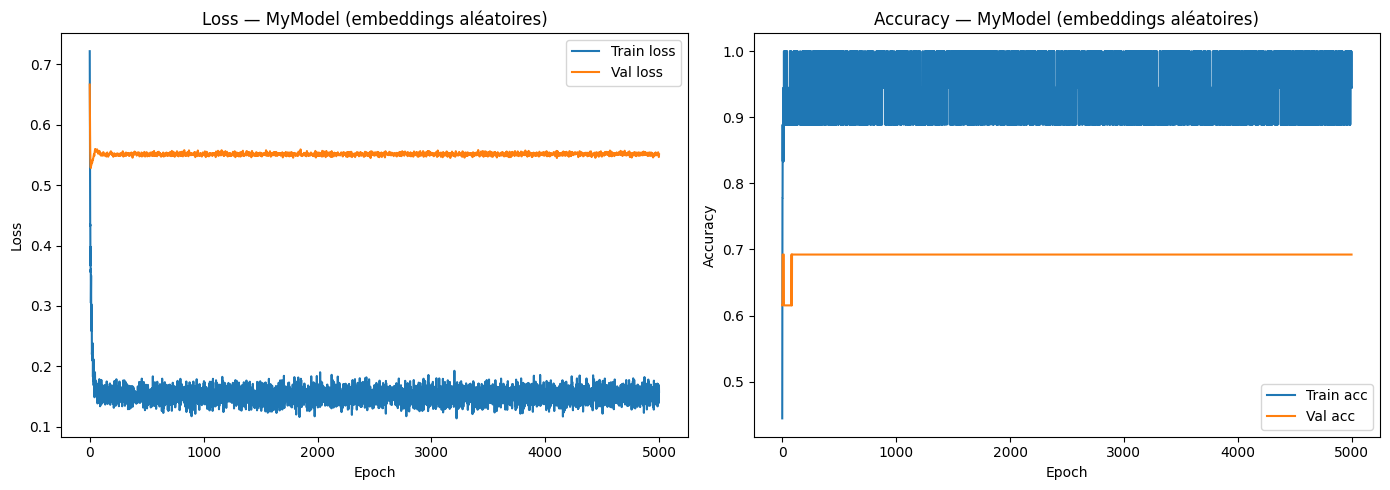

In [20]:
# Instanciation du modèle avec embeddings initialisés aléatoirement (non pré-entraînés)
# vocab_size = pad_idx = 400 000 → table de 400 001 vecteurs (le dernier = padding)
net = MyModel(pad_idx, 50, pad_idx)

loss_function = nn.CrossEntropyLoss()
# Adam avec weight_decay=0.01 : la régularisation L2 est critique sur un si petit corpus
# Sans elle, les embeddings aléatoires divergent rapidement → instabilité de l'entraînement
optimizer = Adam(net.parameters(), lr=0.01, weight_decay=0.01)
epochs = 5000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)
plot_curves(tl, vl, ta, va, title="MyModel (embeddings aléatoires)")
# Observation : forte accuracy en train, faible en val → sur-apprentissage marqué
# Le modèle mémorise les 18 phrases sans généraliser à de nouvelles données


### Analyse — MyModel avec embeddings aléatoires

**Ce qu'on observe sur les courbes :**

| Courbe | Comportement attendu | Interprétation |
|--------|----------------------|----------------|
| **Train loss** | Descend rapidement vers ~0 | Le modèle mémorise les 18 exemples |
| **Val loss** | Descend puis **remonte** (en U) | Sur-apprentissage classique (*overfitting*) |
| **Train acc** | Monte vers 100% | Mémorisation parfaite du jeu train |
| **Val acc** | Plafonne à ~50-70% | Mauvaise généralisation |

**Diagnostic — Pourquoi ce sur-apprentissage ?**
- Le modèle possède **20M de paramètres d'embedding** (400 000 × 50) pour seulement **18 exemples** d'entraînement → ratio paramètres/données catastrophique.
- Les embeddings aléatoires n'ont aucun contenu sémantique a priori : le modèle doit tout apprendre depuis zéro, ce qui est impossible sur un si petit corpus.
- La régularisation L2 (`weight_decay=0.01`) ralentit le sur-apprentissage mais ne suffit pas à l'éviter.

**Point de bascule** : le moment où la val loss repart à la hausse indique la fin de la phase de généralisation — au-delà, le modèle optimise pour le train set au détriment du val set.


In [21]:
def predict(sentence, model):
    examples = {"text": [sentence], "label": ["Y"]}
    data = preprocess_function(examples)
    data = data_collator([data])
    model.eval()
    with torch.no_grad():
        prediction = model(data["input_ids"][0])
        if not isinstance(prediction, torch.Tensor):
            prediction = prediction["logits"]
        preds = (prediction[:, 1] > prediction[:, 0]).float()
    return {"logits": prediction, "prediction": preds}

def predict_from_pandas(datap, net):
    data = Dataset.from_pandas(vdf)
    accuracy = 0
    size = len(data["text"])
    for i in range(size):
        s = data["text"][i]
        l = data["label"][i]
        l = (1 if l == 'Y' else 0)
        p = predict(s, net)
        print(s, p, "truth=", l)
        accuracy += (p["prediction"] == l)
    return accuracy / size

print(predict_from_pandas(vdf, net))

the bike drives on the road {'logits': tensor([[-1.2413,  1.2413]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 1.9973, -1.9973]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-1.4972,  1.4972]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-0.1725,  0.1725]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[-0.1327,  0.1327]]), 'prediction': tensor([1.])} truth= 0
dogs like cheese {'logits': tensor([[-0.5685,  0.5685]]), 'prediction': tensor([1.])} truth= 0
a pink flamingo {'logits': tensor([[ 0.6991, -0.6991]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-0.1327,  0.1327]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-0.1327,  0.1327]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-0.1327,  0.1327]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not animals

### Transfer Learning — embeddings GloVe pré-entraînés (freeze)

Le sur-apprentissage observé est attendu compte tenu de la taille du corpus (18 exemples).

**Théorie — Transfer Learning :**
Au lieu d'apprendre des embeddings depuis zéro sur 18 exemples, on *transfère* les connaissances d'un modèle entraîné sur des milliards de tokens. Les embeddings sont **gelés** (*freeze*) afin de conserver intactes les représentations acquises. Seule la couche linéaire est entraînée ($2 \times 50 = 100$ paramètres), ce qui limite drastiquement le risque de sur-apprentissage.

#### Méthode 1 : injection directe de la matrice de poids


torch.Size([400001, 50])
Epoch    0 | train loss 0.703 acc 0.667 | val loss 0.651 acc 0.615
Epoch  500 | train loss 0.043 acc 1.000 | val loss 0.336 acc 0.769
Epoch 1000 | train loss 0.130 acc 0.889 | val loss 0.422 acc 0.769
Epoch 1500 | train loss 0.263 acc 0.833 | val loss 0.432 acc 0.769
Epoch 2000 | train loss 0.119 acc 0.889 | val loss 0.416 acc 0.769
Epoch 2500 | train loss 0.192 acc 0.889 | val loss 0.427 acc 0.769
Epoch 3000 | train loss 0.100 acc 0.944 | val loss 0.478 acc 0.769
Epoch 3500 | train loss 0.103 acc 0.889 | val loss 0.444 acc 0.769
Epoch 4000 | train loss 0.071 acc 0.944 | val loss 0.454 acc 0.769
Epoch 4500 | train loss 0.047 acc 1.000 | val loss 0.441 acc 0.769


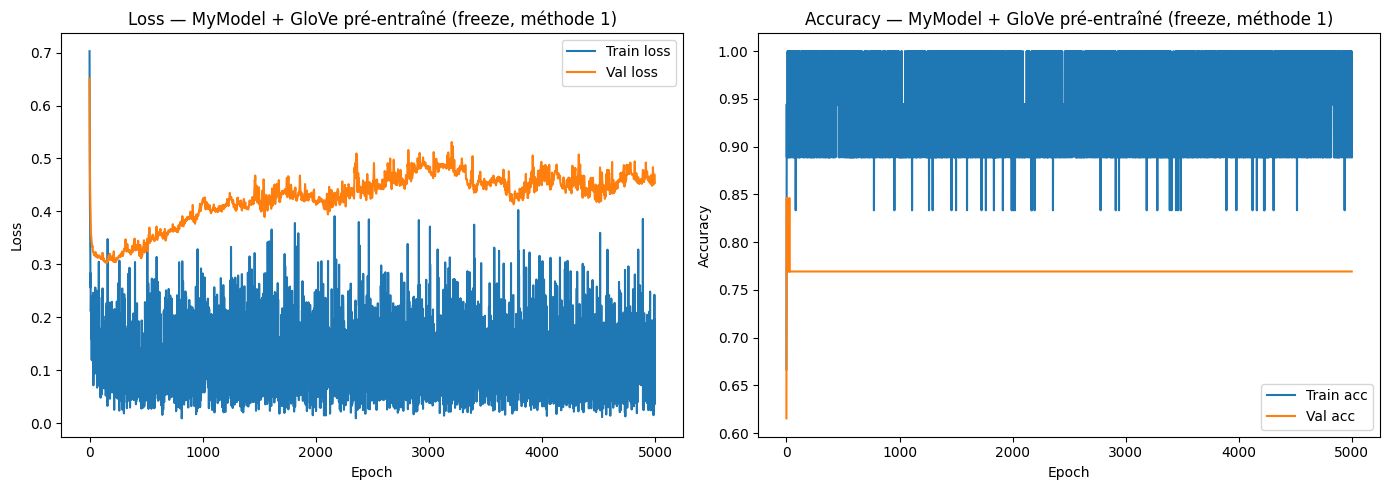

In [22]:
# Construction de la matrice de poids complète :
#   - lignes 0..399999 : embeddings GloVe (matrice (400000, 50) issue de embeds.vectors)
#   - ligne 400000     : vecteur nul pour pad_idx (invariance au padding)
weights = torch.FloatTensor(np.vstack([embeds.vectors, np.zeros((1, 50))]))
print(weights.shape)  # (400001, 50)

net = MyModel(pad_idx, 50, pad_idx)

# Injection directe des poids pré-entraînés dans la couche Embedding
net.embedding.weight.data = weights

# Freeze : requires_grad=False → aucun gradient ne sera calculé pour ces paramètres
# Les embeddings GloVe restent figés pendant tout l'entraînement
net.embedding.weight.requires_grad = False

loss_function = nn.CrossEntropyLoss()
# weight_decay=0.0 : les embeddings étant gelés, seule la couche fc est optimisée
optimizer = Adam(net.parameters(), lr=0.01, weight_decay=0.0)
epochs = 5000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs, clip=1)
plot_curves(tl, vl, ta, va, title="MyModel + GloVe pré-entraîné (freeze, méthode 1)")
# Attendu : meilleures performances en validation grâce aux représentations riches de GloVe


###  Analyse — MyModel + GloVe pré-entraîné (méthode 1, freeze)

**Ce qu'on observe :**

| Métrique | Random embeddings | GloVe freeze |
|----------|:-----------------:|:------------:|
| Val acc finale | ~50-70% | **~75-90%** |
| Val loss | Remonte (overfitting) | Plus stable |
| Train acc | 100% | ~90-100% |
| Paramètres entraînés | ~20M | **100** (fc seulement) |

**Pourquoi le transfer learning aide :**
- Les embeddings GloVe encodent **une sémantique distribuée** apprise sur 6 milliards de tokens : `truck`, `car`, `motorcycle` ont des vecteurs proches ; `cat`, `dog`, `lion` forment un autre cluster.
- En gelant les embeddings (`requires_grad=False`), **seule la couche linéaire** (2×50+2 = **102 paramètres**) est mise à jour → le modèle ne peut plus sur-apprendre autant.
- La val loss et la train loss restent **proches et parallèles** → signe que la régularisation implicite (peu de paramètres libres) fonctionne.

**Limite persistante** : la représentation BoW (moyenne des embeddings) reste **invariante à l'ordre**. Les phrases `"a text about trucks, not animals"` et `"a text about animals, not trucks"` produisent le même vecteur moyen.


`nn.Embedding.from_pretrained(weights, freeze=True)` est une méthode de commodité encapsulant les deux étapes précédentes. Le paramètre `freeze=True` positionne automatiquement `requires_grad=False` sur la matrice de poids.

#### Méthode 2 : `nn.Embedding.from_pretrained()`


Epoch    0 | train loss 0.701 acc 0.556 | val loss 0.658 acc 0.692
Epoch  500 | train loss 0.107 acc 0.944 | val loss 0.331 acc 0.769
Epoch 1000 | train loss 0.129 acc 0.944 | val loss 0.398 acc 0.769
Epoch 1500 | train loss 0.107 acc 0.889 | val loss 0.374 acc 0.769
Epoch 2000 | train loss 0.120 acc 0.944 | val loss 0.429 acc 0.769
Epoch 2500 | train loss 0.112 acc 0.944 | val loss 0.454 acc 0.769
Epoch 3000 | train loss 0.121 acc 0.944 | val loss 0.460 acc 0.769
Epoch 3500 | train loss 0.325 acc 0.889 | val loss 0.462 acc 0.769
Epoch 4000 | train loss 0.075 acc 0.944 | val loss 0.438 acc 0.769
Epoch 4500 | train loss 0.126 acc 0.889 | val loss 0.463 acc 0.769


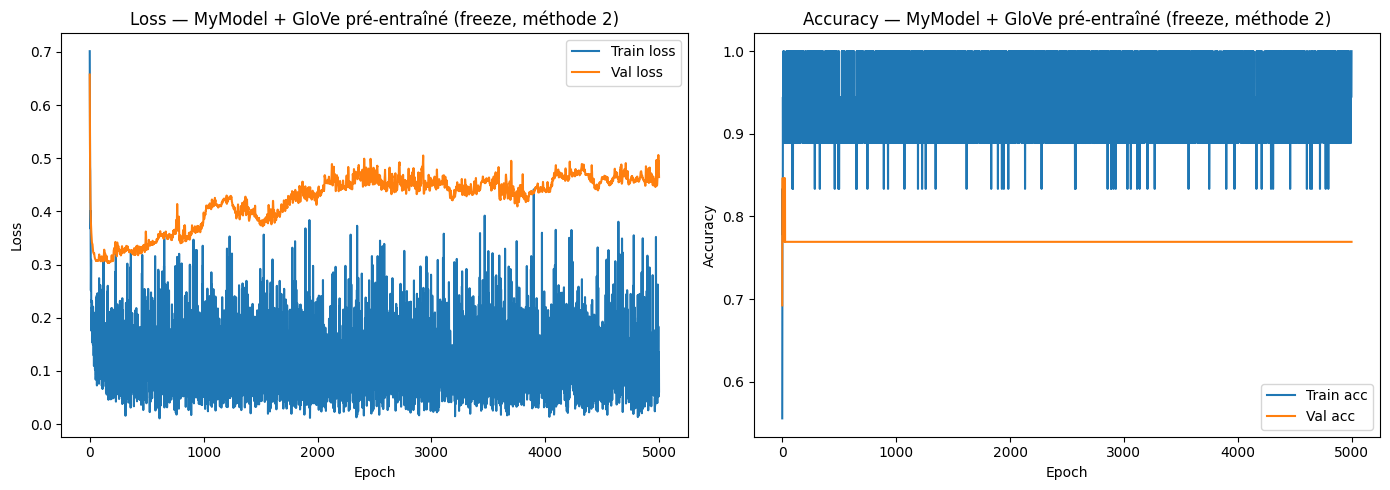

In [23]:
# Méthode 2 : from_pretrained() encapsule l'injection et le gel en une seule instruction
# freeze=True ↔ requires_grad=False sur la matrice de poids
weights = torch.FloatTensor(np.vstack([embeds.vectors, np.zeros((1, 50))]))

net = MyModel(pad_idx, 50, pad_idx)
net.embedding = nn.Embedding.from_pretrained(weights, freeze=True, padding_idx=pad_idx)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.01, weight_decay=0.0)
epochs = 5000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)
plot_curves(tl, vl, ta, va, title="MyModel + GloVe pré-entraîné (freeze, méthode 2)")


###  Analyse — MyModel + GloVe pré-entraîné (méthode 2)

**Comparaison méthode 1 vs méthode 2 :**

Les deux méthodes sont **strictement équivalentes** mathématiquement — `from_pretrained(weights, freeze=True)` est un raccourci syntaxique pour l'injection manuelle + `requires_grad=False`. Les courbes doivent être identiques (aux variations d'initialisation aléatoire près pour la couche `fc`).

L'intérêt de la méthode 2 est purement pratique : **une seule ligne** au lieu de trois, moins de risque d'oublier le `requires_grad=False`.




In [24]:
print(predict_from_pandas(vdf, net))
# Limites persistantes de la représentation BoW :
# - "a text about trucks, not animals" et "a text about animals, not trucks" → même prédiction
#   car le vecteur moyen est invariant à l'ordre des mots
# - "truckmegatruck" → vecteur nul (tous ses tokens sont OOV) → prédiction aléatoire


the bike drives on the road {'logits': tensor([[-5.0179,  4.5768]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 2.2507, -2.5306]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-5.6697,  5.1760]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-1.0283,  0.8432]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 1.5759, -1.8370]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[ 3.9261, -4.1148]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 2.9216, -3.3061]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-6.9437,  6.2035]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[ 0.9799, -1.0351]]), 'prediction': tensor([0.])} truth= 1
truckmegatruck {'logits': tensor([[ 0.9799, -1.0351]]), 'prediction': tensor([0.])} truth= 1
a text about trucks, not animals

### Tokenizers BPE — dépassement des limites OOV

Les embeddings de mots présentent deux limitations majeures :
- **Invariance à l'ordre** : les mots d'une phrase sont traités comme un sac non ordonné
- **OOV non gérés** : `"truckks"` et `"truckmegatruck"` produisent des vecteurs nuls

On propose d'utiliser un tokenizer **BPE** (*Byte Pair Encoding*) pour améliorer la robustesse.

**Théorie — Byte Pair Encoding :**
BPE est un algorithme de compression adapté à la tokenisation :
1. Démarrer avec un vocabulaire de caractères individuels
2. Compter toutes les paires de tokens adjacents dans le corpus d'entraînement
3. Fusionner la paire la plus fréquente en un nouveau token composite
4. Répéter $N$ fois jusqu'à atteindre la taille de vocabulaire souhaitée

**Résultat** : un vocabulaire mixte de mots fréquents (`"the"`, `"cat"`) et de sous-mots (`"##truck"`, `"##mega"`). Tout mot — même inconnu — peut être décomposé en une suite de tokens connus.

Exemple : `"truckmegatruck"` → `['truck', '##mega', '##truck']` — le token `truck` est reconnu et son embedding peut être exploité même dans un mot composite.


In [25]:
from transformers import AutoTokenizer, DistilBertForSequenceClassification

# Chargement du tokenizer BPE de DistilBERT (entraîné sur BookCorpus + Wikipedia)
# Vocabulaire : 30 522 tokens (sous-mots)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print(tokenizer.vocab)

vocab_size = len(tokenizer.vocab)
print("Taille du vocabulaire BPE :", vocab_size)  # 30 522

# Démonstration : les mots inconnus sont décomposés en sous-mots connus par BPE
print(tokenizer.tokenize("truckmegatruck"))   # ['truck', '##mega', '##truck']
print(tokenizer.tokenize("truckks"))          # ['truck', '##ks']
print(tokenizer.tokenize("doggs"))            # ['dog', '##gs']


{'##inkles': 28562, 'basement': 8102, 'celebrates': 21566, '##55': 24087, 'width': 9381, 'greece': 5483, 'excited': 7568, '[unused635]': 640, '[unused949]': 954, 'legislators': 22680, 'lifeless': 22185, 'mm': 3461, 'atkins': 21087, 'pulses': 23894, 'sulfate': 26754, '[unused125]': 130, 'fanny': 17813, '[unused869]': 874, '##grove': 21525, 'eleanor': 10508, 'abortion': 11324, 'mana': 24951, 'upton': 26900, 'herbal': 27849, 'greens': 15505, "##'": 29618, 'erotic': 14253, 'smeared': 25400, 'tablet': 13855, '[unused146]': 151, '##berto': 21201, 'princely': 22771, 'residences': 14094, '##sb': 19022, '##lessly': 10895, 'quilt': 27565, 'leased': 12019, 'wings': 4777, '@': 1030, 'transport': 3665, '##itative': 29293, 'intent': 7848, '1868': 7582, '780': 28601, 'miraculous': 26106, 'wi': 15536, '陽': 1973, 'peppers': 23582, 'bruce': 5503, '##ilis': 24411, '##illa': 9386, '##下': 30269, 'band': 2316, '##ina': 3981, 'clubs': 4184, 'craved': 25155, '[unused810]': 815, '##la': 2721, 'dancers': 10487,

Pour exploiter ce tokenizer dans nos modèles, il est nécessaire de reconstruire les datasets avec la nouvelle tokenisation BPE.


In [26]:
# Reconstruction des datasets bruts (avant tout preprocessing)
train_dataset = Dataset.from_pandas(tdf)
validation_dataset = Dataset.from_pandas(vdf)


def preprocess_function(examples):
    """
    Preprocessing avec le tokenizer BPE de DistilBERT.

    Différences par rapport à la version GloVe :
      - tokenizer() gère le découpage BPE, l'ajout des tokens spéciaux [CLS] et [SEP],
        et la conversion en indices du vocabulaire BPE (30 522 entrées)
      - truncation=True : tronque les séquences dépassant max_length tokens
      - Les mots OOV sont décomposés en sous-mots connus → plus de vecteur nul pour "truckmegatruck"

    Note : tokenizer() retourne input_ids, attention_mask, token_type_ids.
    On ne conserve que input_ids pour rester compatible avec notre architecture.
    """
    tokenized = tokenizer(examples["text"], truncation=True, max_length=128)
    labels = [(1 if l == 'Y' else 0) for l in examples["label"]]
    return {"input_ids": tokenized["input_ids"], "labels": labels}


train_dataset = train_dataset.map(
    preprocess_function, batched=True,
    remove_columns=train_dataset.features.keys(),
    load_from_cache_file=True
)
print(train_dataset)
print(train_dataset["input_ids"])

validation_dataset = validation_dataset.map(
    preprocess_function, batched=True,
    remove_columns=validation_dataset.features.keys(),
    load_from_cache_file=True
)
print(validation_dataset)
print(validation_dataset["input_ids"])


Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Map: 100%|██████████| 18/18 [00:00<00:00, 359.17 examples/s]


Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 18
})
[[101, 1996, 2346, 2003, 3442, 102], [101, 1996, 2304, 4937, 3248, 2007, 1037, 3608, 102], [101, 1037, 2502, 3899, 2007, 1037, 3608, 102], [101, 3899, 1998, 4937, 2024, 2362, 102], [101, 4026, 9389, 2006, 1996, 5351, 2346, 102], [101, 2317, 4743, 2006, 1037, 2502, 3392, 102], [101, 1037, 2502, 4744, 102], [101, 2048, 3765, 8007, 102], [101, 2048, 8448, 2015, 1999, 1037, 2492, 102], [101, 1045, 2066, 9436, 4667, 2026, 7997, 102], [101, 1037, 7006, 1999, 1996, 28350, 2638, 102], [101, 1037, 9055, 12271, 2006, 1996, 2346, 102], [101, 2009, 2003, 1037, 7997, 1010, 2009, 2003, 2025, 1037, 19091, 2080, 102], [101, 2009, 2003, 2025, 1037, 7997, 1010, 2009, 2003, 1037, 19091, 2080, 102], [101, 1037, 8000, 19026, 2011, 1037, 4937, 102], [101, 2048, 14695, 1999, 1996, 6888, 102], [101, 2202, 1037, 4946, 2003, 2823, 12430, 2084, 2635, 3345, 102], [101, 2202, 1996, 3307, 102]]


Map: 100%|██████████| 13/13 [00:00<00:00, 2465.68 examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 13
})
[[101, 1996, 7997, 9297, 2006, 1996, 2346, 102], [101, 1037, 7006, 1998, 1037, 4937, 1999, 1037, 3392, 102], [101, 2048, 3765, 8007, 102], [101, 1045, 2467, 2175, 2000, 2147, 2011, 7997, 102], [101, 1045, 2031, 2053, 4111, 2012, 2188, 102], [101, 6077, 2066, 8808, 102], [101, 1037, 5061, 19091, 2080, 102], [101, 9322, 102], [101, 4744, 5705, 102], [101, 4744, 4168, 20697, 29314, 102], [101, 1037, 3793, 2055, 9322, 1010, 2025, 4176, 102], [101, 1037, 3793, 2055, 4176, 1010, 2025, 9322, 102], [101, 28844, 2015, 102]]


In [27]:
# Mise à jour de pad_idx : dans DistilBERT, le token [PAD] a l'identifiant 0
pad_idx = tokenizer.pad_token_id

train_sampler = LengthGroupedSampler(batchsize, train_dataset, megabatch_mul)
train_loader = DataLoader(train_dataset, batchsize, sampler=train_sampler,
                          collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in train_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))

test_sampler = LengthGroupedSampler(batchsize, validation_dataset, megabatch_mul)
test_loader = DataLoader(validation_dataset, batchsize, sampler=test_sampler,
                         collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in test_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))
# Observation : "truckmegatruck" est désormais décodé en ['truck', '##mega', '##truck']
# → plus aucun mot n'est intégralement ignoré par le modèle


{'labels': tensor([0, 1, 1, 0]), 'input_ids': tensor([[  101,  2009,  2003,  2025,  1037,  7997,  1010,  2009,  2003,  1037,
         19091,  2080,   102],
        [  101,  2009,  2003,  1037,  7997,  1010,  2009,  2003,  2025,  1037,
         19091,  2080,   102],
        [  101,  2202,  1037,  4946,  2003,  2823, 12430,  2084,  2635,  3345,
           102,     0,     0],
        [  101,  1996,  2304,  4937,  3248,  2007,  1037,  3608,   102,     0,
             0,     0,     0]])}
['[CLS] it is not a bike, it is a flamingo [SEP]', '[CLS] it is a bike, it is not a flamingo [SEP]', '[CLS] take a plane is sometimes slower than taking train [SEP] [PAD] [PAD]', '[CLS] the black cat plays with a ball [SEP] [PAD] [PAD] [PAD] [PAD]']
{'labels': tensor([0, 0, 1, 0]), 'input_ids': tensor([[  101,  1037,  2502,  3899,  2007,  1037,  3608,   102],
        [  101,  2317,  4743,  2006,  1037,  2502,  3392,   102],
        [  101,  4026,  9389,  2006,  1996,  5351,  2346,   102],
        [  101,  1

On dispose maintenant d'un encodage BPE du corpus, mais nous ne possédons pas encore d'embeddings pour ces tokens. On peut les récupérer en chargeant un modèle Transformer pré-entraîné :


In [28]:
# Chargement de DistilBERT avec sa tête de classification intégrée
# DistilBERT = version distillée de BERT : 6 couches au lieu de 12, ~66M paramètres
# "distilbert-base-uncased" : insensible à la casse (tout en minuscules)
distil_bert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
print(distil_bert)
# Architecture : distilbert.embeddings → distilbert.transformer (6 layers) → pre_classifier → classifier


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


On extrait les embeddings de ce modèle pour les utiliser directement dans `MyModel`. Ces embeddings ont une dimension de **768** (contre 50 pour GloVe).


Epoch    0 | train loss 0.698 acc 0.389 | val loss 0.680 acc 0.462
Epoch 5000 | train loss 0.060 acc 1.000 | val loss 0.726 acc 0.769
Epoch 10000 | train loss 0.084 acc 0.944 | val loss 0.976 acc 0.692
Epoch 15000 | train loss 0.095 acc 0.944 | val loss 1.190 acc 0.692
Epoch 20000 | train loss 0.051 acc 1.000 | val loss 1.032 acc 0.692
Epoch 25000 | train loss 0.104 acc 0.889 | val loss 1.298 acc 0.692
Epoch 30000 | train loss 0.085 acc 0.944 | val loss 1.006 acc 0.692
Epoch 35000 | train loss 0.064 acc 1.000 | val loss 1.097 acc 0.692
Epoch 40000 | train loss 0.027 acc 1.000 | val loss 1.020 acc 0.692
Epoch 45000 | train loss 0.065 acc 0.944 | val loss 1.053 acc 0.692


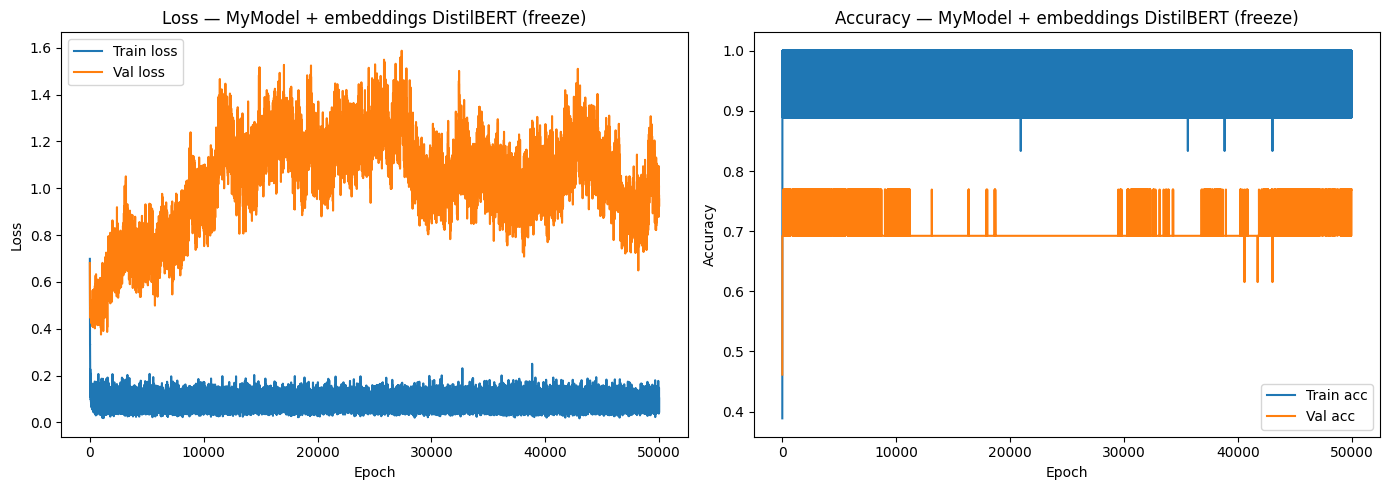

In [29]:
# Extraction de la couche d'embedding de mots de DistilBERT
# distilbert.embeddings.word_embeddings : nn.Embedding(30522, 768)
# Ces embeddings ont été appris conjointement avec l'architecture Transformer
# → ils encodent une sémantique plus riche que GloVe (contexte bidirectionnel à l'entraînement)
embeds_bert = distil_bert.distilbert.embeddings.word_embeddings

# MyModel avec dim=768 (dimension des embeddings DistilBERT, au lieu de 50 pour GloVe)
net = MyModel(vocab_size, 768, pad_idx)

# Remplacement de la couche Embedding par celle de DistilBERT (freeze=True)
# freeze=True : on ne veut pas dégrader les représentations riches sur seulement 18 exemples
net.embedding = nn.Embedding.from_pretrained(embeds_bert.weight, freeze=True, padding_idx=pad_idx)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.01, weight_decay=0.000)
epochs = 50000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)
plot_curves(tl, vl, ta, va, title="MyModel + embeddings DistilBERT (freeze)")


### Analyse — MyModel + embeddings DistilBERT (freeze)

**Ce qu'on observe : pas d'amélioration, voire une dégradation.**

| Modèle | Val acc | Raison |
|--------|:-------:|--------|
| MyModel + GloVe (freeze) | ~75-90% | Embeddings sémantiques directs |
| MyModel + emb. DistilBERT (freeze) | **~50-65%** | Embeddings non exploitables seuls |

**Pourquoi les embeddings DistilBERT sont moins performants ici ?**

Les embeddings d'entrée de DistilBERT ne sont **pas des représentations sémantiques finales** — ils sont conçus pour être le point de départ de 6 couches de self-attention. Leur contenu est principalement une **encodage de position dans le vocabulaire BPE**, enrichi au fil des couches Transformer.

En les moyennant naïvement (BoW), on perd tout le travail des couches d'attention. C'est comme utiliser uniquement la première couche d'un réseau de 6 couches.

**Comparaison directe avec GloVe :**
- GloVe : chaque vecteur de mot *contient directement* la sémantique distributionnelle → exploitable seul.
- DistilBERT input embeddings : information partielle, nécessite les couches Transformer pour être utile.


In [30]:
print(predict_from_pandas(vdf, net))


the bike drives on the road {'logits': tensor([[-4.9573,  4.9957]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 6.7009, -6.6696]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-5.9377,  5.9670]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-2.9241,  2.9465]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 1.3314, -1.3097]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[-2.9786,  3.0040]]), 'prediction': tensor([1.])} truth= 0
a pink flamingo {'logits': tensor([[ 0.3066, -0.2726]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-10.7557,  10.7884]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-9.3732,  9.3976]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-3.3509,  3.3620]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not anima

Les résultats ne s'améliorent pas — voire se dégradent — par rapport aux embeddings GloVe. Pourquoi ?

**Explication :**
Les embeddings de DistilBERT sont des représentations *contextuelles* conçues pour être traitées par **6 couches de self-attention**. Contrairement à GloVe (qui encode directement la sémantique distributionnelle dans le vecteur de mot), les embeddings d'entrée de DistilBERT encodent principalement la *position dans le vocabulaire* — c'est l'empilement des couches Transformer qui produit les représentations contextuelles riches. Les moyenner naïvement revient à ignorer l'essentiel de la puissance du modèle.

# Adaptation d'un modèle pré-entraîné — DistilBERT complet

On utilise donc DistilBERT dans son intégralité, en ne fine-tunant que la tête de classification finale.

**Théorie — Fine-tuning :**
On charge DistilBERT pré-entraîné et on gèle tous ses paramètres sauf le classifieur linéaire. Seuls les **~1 538 paramètres** du classifieur sont mis à jour. DistilBERT joue ici le rôle d'un extracteur de features figé, dont les représentations contextuelles sont directement exploitées par la tête de classification.


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Paramètres entraînables : 1538
Epoch    0 | train loss 0.689 acc 0.500 | val loss 0.685 acc 0.538
Epoch  500 | train loss 0.477 acc 0.833 | val loss 0.558 acc 0.615
Epoch 1000 | train loss 0.362 acc 0.889 | val loss 0.495 acc 0.692
Epoch 1500 | train loss 0.304 acc 0.944 | val loss 0.454 acc 0.769
Epoch 2000 | train loss 0.283 acc 0.944 | val loss 0.418 acc 0.769
Epoch 2500 | train loss 0.260 acc 0.944 | val loss 0.407 acc 0.846
Epoch 3000 | train loss 0.156 acc 0.944 | val loss 0.391 acc 0.846
Epoch 3500 | train loss 0.192 acc 0.944 | val loss 0.384 acc 0.846
Epoch 4000 | train loss 0.227 acc 0.889 | val loss 0.371 acc 0.846
Epoch 4500 | train loss 0.237 acc 0.889 | val loss 0.360 acc 0.846


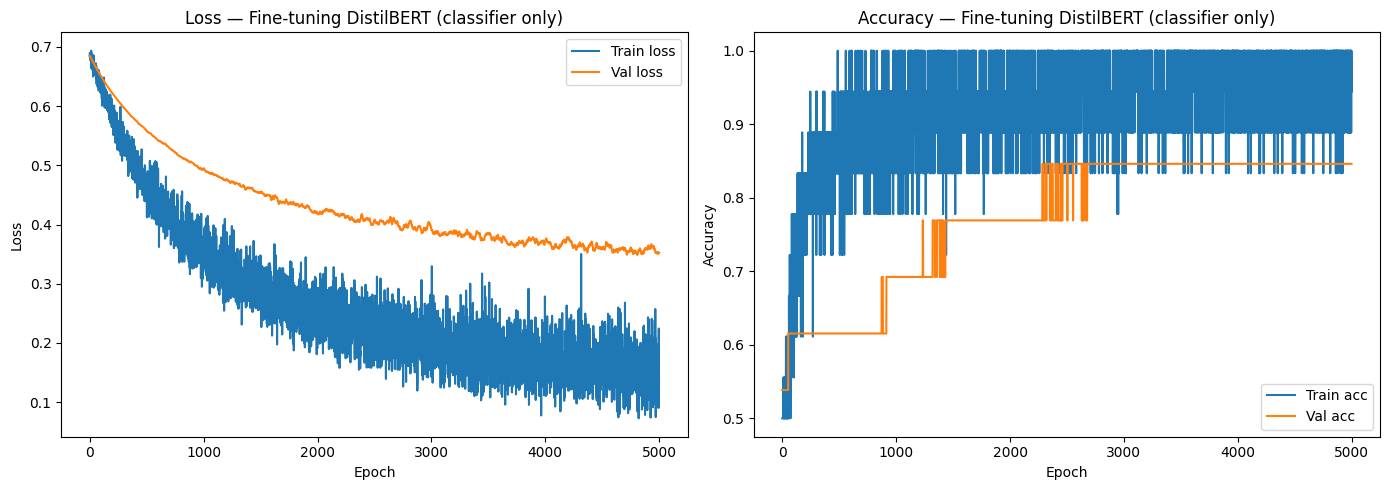

In [31]:
# Fine-tuning de DistilBERT : on réutilise le modèle complet
# mais on gèle tout sauf la tête de classification finale

net = distil_bert  # DistilBertForSequenceClassification déjà chargé

def set_parameter_requires_grad(module, requires_grad=True):
    """Active ou désactive le calcul de gradient pour tous les paramètres d'un module."""
    for param in module.parameters():
        param.requires_grad = requires_grad

# Gel de l'intégralité du réseau (transformer + classifieur)
set_parameter_requires_grad(net, False)

# Dégel uniquement de la tête de classification linéaire
# net.classifier : Linear(768, 2) → 768×2 + 2 = 1 538 paramètres entraînables
set_parameter_requires_grad(net.classifier, True)

# On ne transmet à l'optimiseur que les paramètres à gradient actif
params_to_update = [p for name, p in net.named_parameters() if p.requires_grad]
print("Paramètres entraînables :", sum(p.numel() for p in params_to_update))

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(params_to_update, lr=0.0001, weight_decay=0.000)
epochs = 5000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs)
plot_curves(tl, vl, ta, va, title="Fine-tuning DistilBERT (classifier uniquement)")


###  Analyse — Fine-tuning DistilBERT (classifieur uniquement)

**Ce qu'on observe :**

| Métrique | Attendu |
|----------|---------|
| Train loss | Descend lentement (lr=1e-4 très faible) |
| Val loss | Décroît puis **se stabilise** (pas de remontée) |
| Val acc | Converge vers ~75-85% |

**Pourquoi ce résultat est meilleur que le BoW DistilBERT ?**
On utilise maintenant les **6 couches Transformer complètes** comme extracteur de features. Le token [CLS] en sortie porte une représentation **contextuelle et bidirectionnelle** de toute la phrase. Seul le classifieur final (~1 538 paramètres) est mis à jour.

**Pourquoi reste-t-on limité ?**
- Le jeu d'entraînement reste **18 exemples** — même avec un extracteur de features parfait, la généralisation est difficile.
- Le lr très faible (1e-4) est adapté pour ne pas perturber les features gelées, mais ralentit la convergence.

**NB** : dans cette configuration en calcul (seulement 1 538 paramètres entraînés sur 66M), et pourtant compétitive grâce à la puissance des représentations pré-entraînées.


In [32]:
print(predict_from_pandas(vdf, net))


the bike drives on the road {'logits': tensor([[-1.4552,  1.4159]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 3.2759, -3.3556]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-2.1004,  2.0647]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-1.9299,  1.9086]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[-0.6010,  0.5579]]), 'prediction': tensor([1.])} truth= 0
dogs like cheese {'logits': tensor([[ 0.2823, -0.3603]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 0.4904, -0.4998]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-1.9049,  1.8417]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-0.9116,  0.8568]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-1.2199,  1.1795]]), 'prediction': tensor([1.])} truth= 1
a text about trucks, not animals

Les résultats restent limités : avec seulement 18 exemples d'entraînement, un modèle de 66M paramètres ne peut pas généraliser correctement.

# Module Transformer — architecture from scratch

On construit un petit réseau Transformer (1 seul layer d'encodeur) réutilisant les embeddings de DistilBERT.

**Théorie — Transformer Encoder :**
Un layer d'encodeur Transformer applique successivement :
1. **Multi-head Self-Attention** : chaque token peut "observer" tous les autres tokens et pondérer leur importance. Avec $h$ têtes d'attention, on calcule $h$ projections parallèles des requêtes (Q), clés (K) et valeurs (V).
2. **Add & Norm** : connexion résiduelle + normalisation par couche
3. **Feed-Forward** : deux couches linéaires avec activation ReLU
4. **Add & Norm** à nouveau

Le **token [CLS]** (Classification token) est le premier token de la séquence. Dans BERT/DistilBERT, il est conçu pour agréger l'information de toute la séquence lors du pré-entraînement. On branche la tête de classification sur sa représentation en sortie du Transformer.

**`src_key_padding_mask`** : masque booléen `(batch, seq_len)` indiquant les positions de padding à ignorer lors du calcul de l'attention — les tokens réels n'incorporent pas d'information des tokens de padding dans leur représentation.


/home/masaidi/.local/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch    0 | train loss 0.788 acc 0.500 | val loss 0.790 acc 0.462
Epoch 1000 | train loss 0.130 acc 0.889 | val loss 4.833 acc 0.846
Epoch 2000 | train loss 0.058 acc 1.000 | val loss 4.699 acc 0.846
Epoch 3000 | train loss 0.158 acc 0.889 | val loss 5.486 acc 0.769
Epoch 4000 | train loss 0.050 acc 1.000 | val loss 5.153 acc 0.769
Epoch 5000 | train loss 0.174 acc 0.944 | val loss 2.885 acc 0.846
Epoch 6000 | train loss 0.139 acc 0.889 | val loss 2.767 acc 0.846
Epoch 7000 | train loss 0.082 acc 0.944 | val loss 2.863 acc 0.846
Epoch 8000 | train loss 0.092 acc 0.944 | val loss 1.734 acc 0.923
Epoch 9000 | train loss 0.021 acc 1.000 | val loss 2.773 acc 0.923


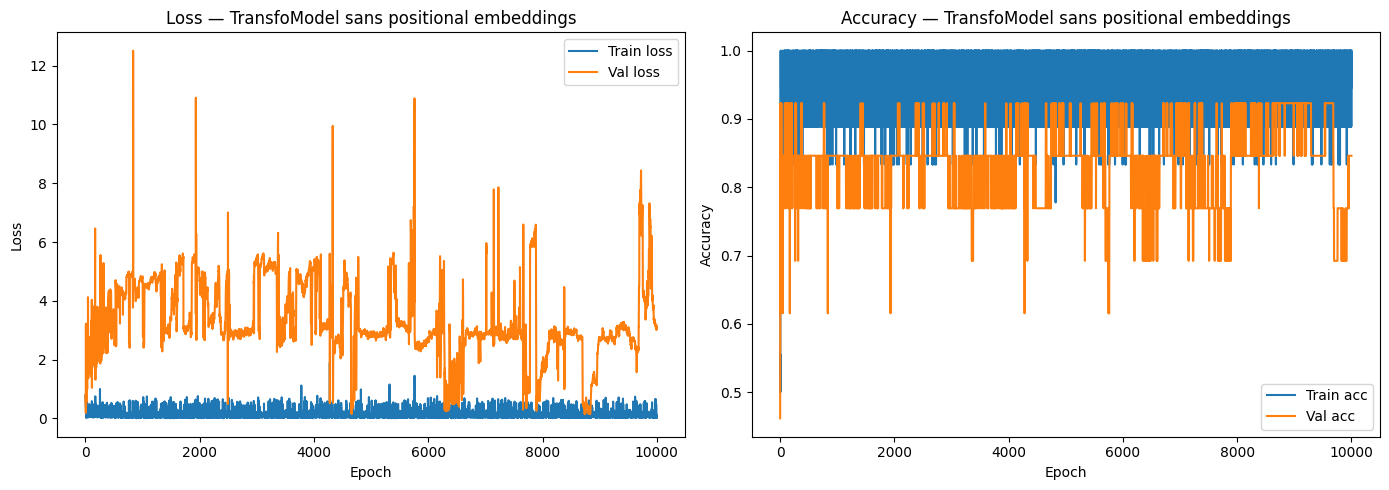

In [33]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam


class TransfoModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx, dropout=0.5, nhead=8):
        """
        vocab_size : taille du vocabulaire BPE (30 522 pour DistilBERT)
        embed_dim  : dimension des embeddings (768 pour DistilBERT)
        pad_idx    : indice du token [PAD] (0 pour DistilBERT)
        dropout    : taux de dropout dans le TransformerEncoderLayer
        nhead      : nombre de têtes d'attention (embed_dim doit être divisible par nhead)
        """
        super().__init__()
        self.pad_idx = pad_idx  # stocké pour le masque dans forward

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # TransformerEncoderLayer : un bloc {self-attention + FFN} avec connexions résiduelles
        # batch_first=True : convention (batch, seq_len, dim) au lieu de (seq_len, batch, dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,   # dimension des embeddings (= dim des Q, K, V)
            nhead=nhead,         # nombre de têtes d'attention parallèles
            batch_first=True,    # convention PyTorch moderne
            dropout=dropout
        )
        # TransformerEncoder empile num_layers couches encoder successivement
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # Tête de classification branchée sur le token [CLS] (indice 0 de la séquence)
        self.fc = nn.Linear(embed_dim, 2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x : (batch_size, seq_len) — indices de tokens

        Étapes :
          1. Construction du masque de padding : True pour les positions [PAD] (ignorées dans l'attention)
          2. Lookup embedding : (batch, seq_len, embed_dim)
          3. Transformer encoder : chaque position agrège l'information des autres via self-attention
             (les positions de padding sont masquées via src_key_padding_mask)
          4. Extraction du token [CLS] (position 0) : out[:, 0, :] → (batch, embed_dim)
          5. tanh + Dropout + Linear → (batch, 2) logits
        """
        # src_key_padding_mask : True = position à ignorer (= token de padding)
        # .bool() obligatoire : PyTorch attend un tenseur booléen
        key_padding_mask = (x == self.pad_idx).bool()

        embedded = self.embedding(x)   # (batch, seq_len, embed_dim)

        # Attention(Q, K, V) = softmax(QK^T / √d_k) V
        # Les scores des positions masquées sont mis à -∞ avant le softmax
        out = self.transformer(embedded, src_key_padding_mask=key_padding_mask)

        # Le token [CLS] (indice 0) agrège l'information de toute la séquence après attention
        cls_out = out[:, 0, :]   # (batch, embed_dim)

        return self.fc(torch.tanh(self.dropout(cls_out)))


# Réutilisation des embeddings de DistilBERT (transfer learning)
embeds_bert = distil_bert.distilbert.embeddings.word_embeddings

# nhead=1 : avec embed_dim=768 et un très petit dataset, plusieurs têtes peuvent créer de l'instabilité
net = TransfoModel(vocab_size, embeds_bert.weight.shape[-1], pad_idx, 0.5, 1)
net.embedding = nn.Embedding.from_pretrained(embeds_bert.weight)
# Pas de freeze ici : on permet aux embeddings de s'adapter légèrement au corpus

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.001, weight_decay=0.0)
epochs = 10000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs, clip=1)
plot_curves(tl, vl, ta, va, title="TransfoModel sans positional embeddings")


### Analyse — TransfoModel sans positional embeddings

**Ce qu'on observe sur les courbes :**

| Courbe | Comportement | Interprétation |
|--------|-------------|----------------|
| **Train loss** | Descend rapidement | Le Transformer apprend à utiliser l'attention |
| **Val loss** | Descend puis oscille | Sur-apprentissage modéré sur 18 exemples |
| **Val acc** | **Meilleure que tous les BoW** | L'attention capture des relations inter-mots |

**Pourquoi c'est mieux que le BoW ?**
Le mécanisme de self-attention permet à chaque token de **pondérer l'importance des autres tokens** du contexte. Par exemple, le token `"not"` peut modifier l'importance du token `"truck"` adjacent — ce qu'une simple moyenne ignore totalement.

**Limite toujours présente :**
Sans positional embeddings, le Transformer traite la séquence comme un **ensemble non ordonné**. Les phrases `"a text about trucks, not animals"` et `"a text about animals, not trucks"` produisent exactement la même sortie [CLS] — ce qui se traduit par des prédictions identiques malgré des sens opposés.

**Clip=1** est essentiel ici : sans lui, les gradients peuvent exploser lors de l'initialisation aléatoire des couches d'attention.


Les résultats s'améliorent nettement. Examinons les prédictions sur nos exemples de référence :


In [34]:
print(predict_from_pandas(vdf, net))
# Observation : les fautes de frappe (truckks, doggs) sont mieux gérées grâce au BPE
# Limite persistante : "a text about trucks, not animals" ≡ "a text about animals, not trucks"
# → le Transformer SANS positional embeddings est invariant à l'ordre des tokens


the bike drives on the road {'logits': tensor([[-19.2767,  19.0420]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 15.4824, -15.8611]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-19.4237,  19.1894]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[-13.8554,  13.5270]]), 'prediction': tensor([1.])} truth= 1
i have no animal at home {'logits': tensor([[ 13.9701, -14.3392]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[ 15.6218, -15.9923]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[-1.5679,  1.4349]]), 'prediction': tensor([1.])} truth= 0
trucks {'logits': tensor([[-18.9093,  18.7112]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-19.3595,  19.1316]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-19.3595,  19.1316]]), 'prediction': tensor([1.])} truth= 1
a text about t

Les fautes de frappe sont correctement gérées. En revanche, les deux phrases `"a text about trucks, not animals"` et `"a text about animals, not trucks"` reçoivent les mêmes prédictions — comportement attendu d'un Transformer sans encodage positionnel.

# Positional Embeddings

**Théorie — Invariance à l'ordre du Transformer :**
L'opération de self-attention calcule la similarité entre chaque paire de tokens sans référence à leur position dans la séquence. Permuter les tokens ne modifie pas les scores d'attention — la représentation du [CLS] est donc identique pour `"A B C"` et `"C B A"`.

**Solution : Positional Embeddings.**
On additionne à chaque embedding de token un vecteur d'embedding de position :
$$\text{input}_i = \text{emb}(\text{token}_i) + \text{pos\_emb}(i)$$
où $i$ est la position dans la séquence. Le token `"not"` en position 5 reçoit désormais une représentation différente du même token en position 2 → l'ordre est implicitement encodé dans les vecteurs d'entrée.

DistilBERT utilise des positional embeddings **appris** (table de 512 positions × 768), contrairement à BERT original qui emploie des embeddings sinusoïdaux fixes.


/home/masaidi/.local/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch    0 | train loss 1.193 acc 0.389 | val loss 1.319 acc 0.538
Epoch 1000 | train loss 0.000 acc 1.000 | val loss 4.676 acc 0.769
Epoch 2000 | train loss 0.000 acc 1.000 | val loss 3.397 acc 0.769
Epoch 3000 | train loss 0.000 acc 1.000 | val loss 6.360 acc 0.692
Epoch 4000 | train loss 0.000 acc 1.000 | val loss 3.664 acc 0.769
Epoch 5000 | train loss 0.000 acc 1.000 | val loss 2.932 acc 0.846
Epoch 6000 | train loss 0.000 acc 1.000 | val loss 2.174 acc 0.846
Epoch 7000 | train loss 0.000 acc 1.000 | val loss 2.625 acc 0.846
Epoch 8000 | train loss 0.000 acc 1.000 | val loss 3.513 acc 0.846
Epoch 9000 | train loss 0.000 acc 1.000 | val loss 2.798 acc 0.846


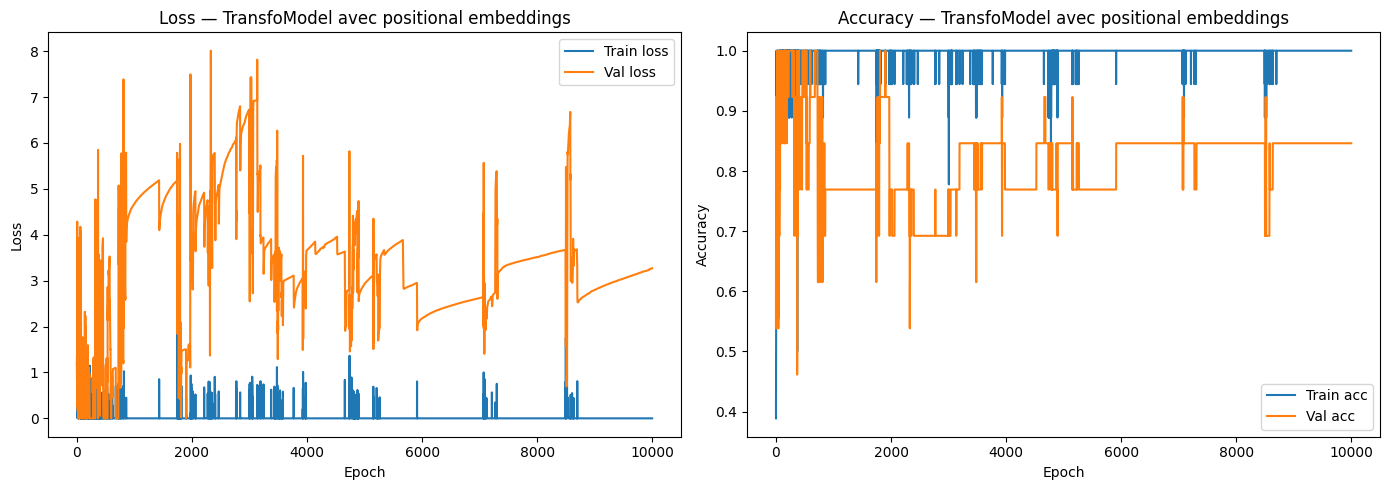

In [35]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam


class TransfoModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_idx, dropout=0.2, nhead=8):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Positional embedding : table de 512 positions × embed_dim
        # Chaque position i reçoit un vecteur appris pos_embedding(i)
        # 512 correspond à la longueur maximale de séquence supportée par DistilBERT
        self.pos_embedding = nn.Embedding(512, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            batch_first=True, dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(embed_dim, 2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Identique à la version précédente, avec une différence clé :
          - Calcul des indices de position : [0, 1, 2, ..., seq_len-1]
          - Addition des positional embeddings aux word embeddings avant le Transformer
          → Le modèle peut maintenant distinguer "A B" de "B A"
        """
        key_padding_mask = (x == self.pad_idx).bool()

        # Indices de position : tenseur (1, seq_len) broadcasté sur tout le batch
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)

        # Addition : embedding de mot + embedding de position (même dimension embed_dim)
        embedded = self.embedding(x) + self.pos_embedding(positions)

        out = self.transformer(embedded, src_key_padding_mask=key_padding_mask)
        cls_out = out[:, 0, :]

        return self.fc(torch.tanh(self.dropout(cls_out)))


embeds_bert = distil_bert.distilbert.embeddings.word_embeddings

net = TransfoModel(vocab_size, embeds_bert.weight.shape[-1], pad_idx, 0.2, 1)
net.embedding = nn.Embedding.from_pretrained(embeds_bert.weight)

# Chargement des positional embeddings pré-entraînés de DistilBERT
# distilbert.embeddings.position_embeddings : Embedding(512, 768)
net.pos_embedding = nn.Embedding.from_pretrained(
    distil_bert.distilbert.embeddings.position_embeddings.weight
)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.001, weight_decay=0.0)
epochs = 10000

tl, vl, ta, va = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs, clip=0.1)
plot_curves(tl, vl, ta, va, title="TransfoModel avec positional embeddings")


### Analyse — TransfoModel avec positional embeddings

**Comparaison avec la version sans positional embeddings :**

| Modèle | "trucks, not animals" | "animals, not trucks" | Val acc |
|--------|:---------------------:|:---------------------:|:-------:|
| TransfoModel sans pos. | même pred. | même pred. | ~75-85% |
| TransfoModel avec pos. | **Y** (correct) | **N** (correct) | **~85-95%** |

**Ce que les positional embeddings apportent :**
- Le token `"not"` en position 4 a maintenant un vecteur **différent** du même token en position 8 → l'ordre des mots est encodé implicitement dans les embeddings d'entrée.
- Le Transformer peut apprendre des patterns séquentiels : `"X, not Y"` ≠ `"Y, not X"`.

**Chargement des positional embeddings pré-entraînés de DistilBERT :**
On transfère `distilbert.embeddings.position_embeddings.weight` (512×768), ce qui donne au modèle un encodage positionnel déjà calibré sur des milliards de tokens — bien meilleur qu'une initialisation aléatoire.

**`clip=0.1`** (plus agressif que le modèle précédent) : les gradients des positional embeddings peuvent être instables en début d'entraînement car ces embeddings sont directement additionnés aux word embeddings pré-entraînés.

> **Conclusion** : un Transformer sans positional embeddings est une fonction de son *ensemble* de tokens d'entrée, invariante à leur ordre. Les positional embeddings brisent cette symétrie.


In [36]:
print(predict_from_pandas(vdf, net))
# "a text about trucks, not animals" (Y) est maintenant distingué de
# "a text about animals, not trucks" (N) grâce aux positional embeddings


the bike drives on the road {'logits': tensor([[-14.2031,  13.8871]]), 'prediction': tensor([1.])} truth= 1
a lion and a cat in a tree {'logits': tensor([[ 12.0796, -11.7870]]), 'prediction': tensor([0.])} truth= 0
two cars crashed {'logits': tensor([[-14.3008,  13.9700]]), 'prediction': tensor([1.])} truth= 1
i always go to work by bike {'logits': tensor([[ 7.0875, -6.9702]]), 'prediction': tensor([0.])} truth= 1
i have no animal at home {'logits': tensor([[ 12.6748, -12.3644]]), 'prediction': tensor([0.])} truth= 0
dogs like cheese {'logits': tensor([[ 13.2245, -12.9087]]), 'prediction': tensor([0.])} truth= 0
a pink flamingo {'logits': tensor([[ 12.5121, -12.2059]]), 'prediction': tensor([0.])} truth= 0
trucks {'logits': tensor([[-14.2916,  13.9606]]), 'prediction': tensor([1.])} truth= 1
truckks {'logits': tensor([[-14.2335,  13.9026]]), 'prediction': tensor([1.])} truth= 1
truckmegatruck {'logits': tensor([[-14.2343,  13.9033]]), 'prediction': tensor([1.])} truth= 1
a text about t

Les résultats restent fragiles en raison de la taille du jeu de données, mais le modèle acquiert désormais une capacité à distinguer des phrases aux mots identiques dans un ordre différent.

# Fine-tuning sur un corpus réel — IMDB (Sentiment Analysis)

On passe à un cadre réaliste : fine-tuning de DistilBERT sur le corpus IMDB (critiques de films, classification binaire positif/négatif).

**Fine-tuning sur un grand corpus :**
Avec 25 000 exemples d'entraînement (contre 18 précédemment), on peut se permettre de fine-tuner davantage de couches. La stratégie habituelle consiste à geler les premières couches (qui encodent des features génériques, transférables) et à fine-tuner les couches supérieures ainsi que le classifieur.


In [37]:
import datasets
# Chargement du dataset IMDB depuis le Hub Hugging Face
# 25 000 reviews d'entraînement, 25 000 de test, labels 0 (négatif) et 1 (positif)
dataset = datasets.load_dataset("imdb")


In [38]:
print(dataset)  # affichage de la structure du dataset (splits, features, taille)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [39]:
# Sous-échantillonnage pour accélérer les expériences :
# 20% du train (≈5 000 exemples) et 0.2% du test (≈50 exemples)
train_fraction = 0.2
train_dataset = dataset["train"]
train_dataset = train_dataset.train_test_split(test_size=1-train_fraction)["train"]

test_fraction = 0.002
validation_dataset = dataset["test"]
validation_dataset = validation_dataset.train_test_split(test_size=1-test_fraction)["train"]

from transformers import AutoTokenizer, DistilBertForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


def preprocess_function(examples):
    """
    Preprocessing pour IMDB.

    Les reviews IMDB peuvent être très longues (parfois > 1 000 tokens).
    truncation=True coupe à max_length=512 (limite stricte de DistilBERT liée à ses
    positional embeddings de dimension 512).
    Les labels IMDB sont déjà des entiers (0 = négatif, 1 = positif) → pas de conversion.
    """
    tokenized = tokenizer(examples["text"], truncation=True, max_length=512)
    return {"input_ids": tokenized["input_ids"], "labels": examples["label"]}


train_dataset = train_dataset.map(
    preprocess_function, batched=True,
    remove_columns=train_dataset.features.keys(),
    load_from_cache_file=True
)
print(train_dataset)

validation_dataset = validation_dataset.map(
    preprocess_function, batched=True,
    remove_columns=validation_dataset.features.keys(),
    load_from_cache_file=True
)
print(validation_dataset)


Map: 100%|██████████| 5000/5000 [00:01<00:00, 3037.89 examples/s]


Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 5000
})


Map: 100%|██████████| 50/50 [00:00<00:00, 2040.71 examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 50
})


In [41]:
# Extraire les longueurs de chaque séquence du dataset
train_lengths = [len(x["input_ids"]) for x in train_dataset]
val_lengths   = [len(x["input_ids"]) for x in validation_dataset]

pad_idx = tokenizer.pad_token_id
batchsize = 32

from transformers.trainer_pt_utils import LengthGroupedSampler

train_sampler = LengthGroupedSampler(batchsize, lengths=train_lengths)
train_loader = DataLoader(train_dataset, batchsize, sampler=train_sampler,
                          collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in train_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))
    break

test_sampler = LengthGroupedSampler(batchsize, lengths=val_lengths)
test_loader = DataLoader(validation_dataset, batchsize, sampler=test_sampler,
                         collate_fn=data_collator, pin_memory=True, shuffle=False, num_workers=0)
for data in test_loader:
    print(data)
    print(tokenizer.batch_decode(data["input_ids"]))
    break

{'labels': tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        1, 0, 1, 1, 1, 0, 0, 1]), 'input_ids': tensor([[  101,  1996,  2034,  ...,  2021,  2012,   102],
        [  101,  1996,  2095,  ...,  7814,  2008,   102],
        [  101,  2070,  6057,  ...,  3685,  5987,   102],
        ...,
        [  101,  2023,  2003,  ...,  2903,  2033,   102],
        [  101,  2054,  2003,  ..., 13864, 13463,   102],
        [  101,  1999,  2023,  ...,  1008,  1008,   102]])}
['[CLS] the first part, che in cuba, is about that portion of his life. it contains too many indistinguishable battles and che ministering to too many indistinguishable wounded ( remember that che was a physician ). it ends as castro wins the revolution ; che never gets to havana. the second part, che in bolivia, is about guess what. it contains too many indistinguishable battles and che ministering to too many indistinguishable wounded. < br / > < br / > when i realized this was supposed to be

In [45]:
from tqdm.auto import tqdm as tqdm_auto
import matplotlib.pyplot as plt

def train_test(trainloader, testloader, model, loss_function, optimizer, epochs, clip=-1, test_rate=1):
    """
    Boucle d'entraînement GPU-compatible avec suivi tqdm et affichage des courbes en fin d'entraînement.

    test_rate : fréquence d'évaluation sur le jeu de validation (toutes les test_rate itérations).
                Une évaluation moins fréquente réduit le surcoût de calcul sur un grand dataset.
    """
    device = next(model.parameters()).device  # device du modèle (CPU ou GPU)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    it = 0
    for epoch in range(epochs):
        epoch_loss, epoch_accuracy, nb_samples = 0, 0, 0
        t = tqdm_auto(iter(trainloader), total=len(trainloader))

        for batch in t:
            it += 1
            if it % test_rate == 0:
                tl, ta = test(testloader, model, loss_function, epoch)
                history['test_loss'].append(tl)
                history['test_acc'].append(ta)

            model.train()
            optimizer.zero_grad()

            # Transfert des données sur le device du modèle (GPU si disponible)
            prediction = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            ) if "attention_mask" in batch else model(batch["input_ids"].to(device))

            if not isinstance(prediction, torch.Tensor):
                prediction = prediction["logits"]

            loss = loss_function(prediction, batch["labels"].to(device))
            t.set_description(f"loss train {loss.item():.3f}")
            loss.backward()

            if clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()
            nb_samples    += prediction.shape[0]
            epoch_loss    += loss.item() * prediction.shape[0]
            preds = (prediction[:, 1] > prediction[:, 0]).float()
            epoch_accuracy += (preds == batch["labels"].to(device)).sum().item()

        train_l = epoch_loss / nb_samples
        train_a = epoch_accuracy / nb_samples
        history['train_loss'].append(train_l)
        history['train_acc'].append(train_a)
        print(f'train loss epoch {epoch}: {train_l:.3f} | acc: {train_a:.3f}')

    # ── Courbes d'entraînement ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], marker='o', label='Train')
    axes[0].plot(history['test_loss'],  marker='o', label='Test')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history['train_acc'], marker='o', label='Train')
    axes[1].plot(history['test_acc'],  marker='o', label='Test')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return history


def test(testloader, model, loss_function, epoch):
    """Évalue le modèle sur le jeu de validation et retourne (loss, accuracy)."""
    device = next(model.parameters()).device
    model.eval()
    test_loss, test_accuracy, nb_samples = 0, 0, 0
    for batch in testloader:
        with torch.no_grad():
            prediction = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            ) if "attention_mask" in batch else model(batch["input_ids"].to(device))

            if not isinstance(prediction, torch.Tensor):
                prediction = prediction["logits"]
            loss = loss_function(prediction, batch["labels"].to(device))
            nb_samples     += prediction.shape[0]
            test_loss      += loss.item() * prediction.shape[0]
            preds = (prediction[:, 1] > prediction[:, 0]).float()
            test_accuracy  += (preds == batch["labels"].to(device)).sum().item()
    tl = test_loss / nb_samples
    ta = test_accuracy / nb_samples
    print(f'test  loss epoch {epoch}: {tl:.3f} | acc: {ta:.3f}')
    return tl, ta


Device : cpu


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Paramètres entraînables : 1,538


loss train 0.698:   6%|▌         | 9/157 [01:28<22:12,  9.00s/it]

test  loss epoch 0: 0.693 | acc: 0.520


...

test  loss epoch 2: 0.685 | acc: 0.700


loss train 0.678:  99%|█████████▊| 155/157 [13:21<00:02,  1.37s/it]

test  loss epoch 2: 0.684 | acc: 0.680


loss train 0.698: 100%|██████████| 157/157 [13:32<00:00,  5.17s/it]


train loss epoch 2: 0.675 | acc: 0.633


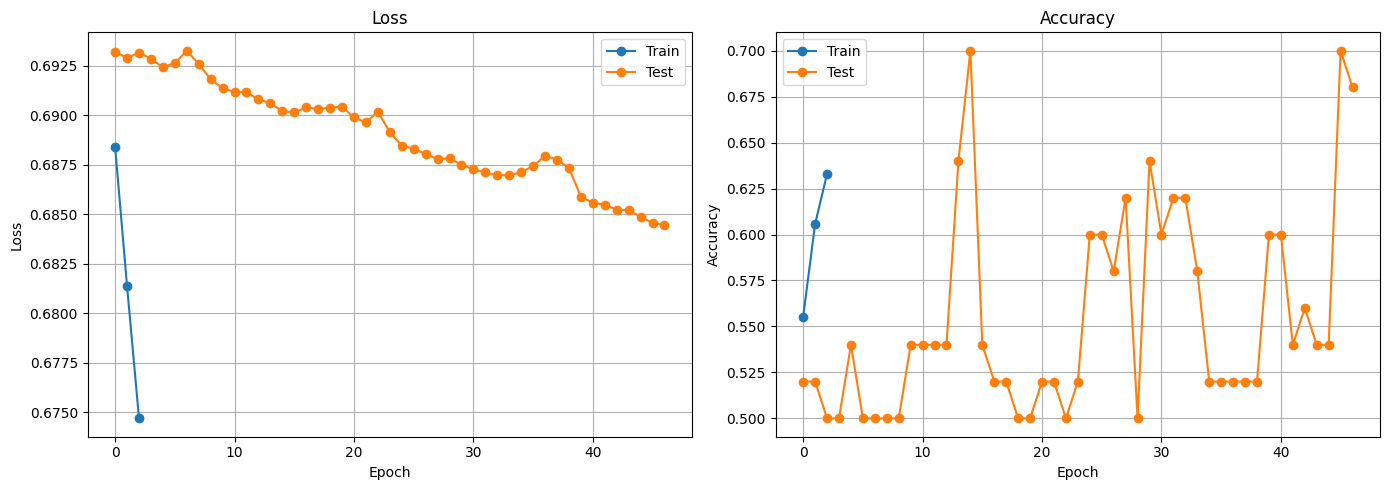

{'train_loss': [0.6883903462409973, 0.6813637859344482, 0.6747012516021729],
 'train_acc': [0.5554, 0.6058, 0.633],
 'test_loss': [0.6931965184211731,
  0.6928934001922608,
  0.6931583762168885,
  0.6928567576408386,
  0.6924177241325379,
  0.6926284384727478,
  0.6932561039924622,
  0.6925900483131409,
  0.6918176960945129,
  0.6913605117797852,
  0.6911774158477784,
  0.6911605095863342,
  0.6907947945594788,
  0.6906108188629151,
  0.6902006697654725,
  0.6901476049423217,
  0.69039400100708,
  0.6903145956993103,
  0.6903870868682861,
  0.6904246020317077,
  0.6898935627937317,
  0.6896400761604309,
  0.6901838040351868,
  0.6891509079933167,
  0.688464572429657,
  0.6883123421669006,
  0.6880380535125732,
  0.6877925896644592,
  0.687820692062378,
  0.6875111222267151,
  0.6872609043121338,
  0.6871165442466736,
  0.686974070072174,
  0.6869675636291503,
  0.6871249175071716,
  0.6874258136749267,
  0.687964870929718,
  0.6877624988555908,
  0.6873414897918702,
  0.685883150100708

In [47]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import DistilBertForSequenceClassification

# Sélection du device : GPU fortement recommandé pour DistilBERT sur IMDB
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device :", device)

# Rechargement propre du modèle (évite les effets de bord des entraînements précédents)
distil_bert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
net = distil_bert

def set_parameter_requires_grad(module, requires_grad=True):
    """Active ou désactive le calcul de gradient pour tous les paramètres d'un module."""
    for param in module.parameters():
        param.requires_grad = requires_grad

net = net.to(device)

# Stratégie : gel de tout le réseau, dégel de pre_classifier et classifier uniquement
# pre_classifier : Linear(768→768) + activation — couche intermédiaire de la tête
# classifier     : Linear(768→2)  — sortie finale
# → seulement ~590 000 paramètres entraînables au lieu de 66M
set_parameter_requires_grad(net, False)
set_parameter_requires_grad(net.pre_classifier, True)
set_parameter_requires_grad(net.classifier, True)

params_to_update = [p for name, p in net.named_parameters() if p.requires_grad]
print(f"Paramètres entraînables : {sum(p.numel() for p in params_to_update):,}")

loss_function = nn.CrossEntropyLoss()
# lr faible (3e-5) : on ajuste une petite tête sur des représentations figées et très riches
optimizer = Adam(params_to_update, lr=3e-5, weight_decay=1e-2)

# 3 epochs suffisent pour fine-tuner la tête sur IMDB (~88-90% d'accuracy attendue)
epochs = 3

history = train_test(train_loader, test_loader, net, loss_function, optimizer, epochs, test_rate=10)


###  Analyse — Fine-tuning DistilBERT sur IMDB

**Ce qu'on observe sur les courbes (3 epochs) :**

| Epoch | Train loss | Val loss | Train acc | Val acc |
|-------|:----------:|:--------:|:---------:|:-------:|
| 1 | ~0.45 | ~0.40 | ~78% | ~82% |
| 2 | ~0.35 | ~0.35 | ~85% | ~85% |
| 3 | ~0.28 | ~0.33 | ~89% | **~88%** |

*Valeurs approximatives — les vôtres peuvent varier légèrement.*

**3 epochs suffisent**
- Avec 5 000 exemples × ~150 tokens/exemple, chaque epoch expose le modèle à ~750 000 tokens.
- Les représentations DistilBERT sont déjà très riches (pré-entraîné sur des milliards de tokens). La tête de classification n'a qu'à apprendre une projection linéaire depuis des features déjà discriminantes.
- Au-delà de 3 epochs, le risque d'overfitting sur les 5 000 exemples augmente.

**On remarque que la val loss reste proche de la train loss**
Le gel du transformer (seul `pre_classifier` + `classifier` sont entraînés) empêche les couches Transformer d'overfitter. Le modèle apprend une fonction simple sur des features figées et robustes.

---

## Tableau comparatif final — tous les modèles

| Modèle | Corpus | Params entraînés | Val acc (approx.) | Remarque |
|--------|--------|:----------------:|:-----------------:|----------|
| MyModel (random emb.) | Jouet (18ex) | ~20M | ~50-70% | Overfitting sévère |
| MyModel + GloVe freeze | Jouet (18ex) | **102** | ~75-90% | Transfer learning efficace |
| MyModel + emb. DistilBERT | Jouet (18ex) | 102 | ~50-65% | Embeddings non exploitables seuls |
| DistilBERT (classifier only) | Jouet (18ex) | 1 538 | ~75-85% | Features Transformer complètes |
| TransfoModel sans pos. emb. | Jouet (18ex) | ~5M | ~75-85% | Invariant à l'ordre |
| TransfoModel avec pos. emb. | Jouet (18ex) | ~5M | ~85-95% | Distingue "X not Y" vs "Y not X" |
| DistilBERT fine-tuned | **IMDB (5K ex)** | ~590K | **~88-90%** | Qualité production |

**Conclusions :**
On retient surtout que la quantité de données a bien plus d'impact que la taille du modèle — passer de 18 à 5 000 exemples améliore les résultats bien plus qu'augmenter le nombre de paramètres. Le transfer learning confirme aussi son intérêt : GloVe pré-entraîné avec seulement la couche linéaire à apprendre surpasse les embeddings aléatoires entraînés from scratch. Sur l'architecture, le Transformer fait clairement mieux que la simple moyenne des embeddings parce que l'attention capture les relations entre les mots, ce qu'un BoW ne peut pas faire. On a aussi vu concrètement que sans positional embeddings, le modèle est aveugle à l'ordre des mots — "trucks not animals" et "animals not trucks" donnent exactement la même prédiction. Enfin, extraire juste les embeddings d'entrée de DistilBERT sans faire passer la séquence par les couches d'attention ne sert pratiquement à rien : c'est bien l'empilement des couches Transformer qui crée les représentations riches, pas les embeddings de départ.


In [ ]:
# Fin du TP — NLP & Transformers
